# EGBE: modelling the evolution gravel-sized alluvium layer and the underlying bedrock in a network of rivers

### This notebook provides a brief introduction and user’s guide to the Extended Gravel Bed Eroder (EGBE) and SoilGrading Landlab components. 

# EGBE Model description
EGBE simulates drainage network evolution for a network of rivers that have a layer of gravel alluvium overlying bedrock, taking into account heterogeneous sizes OR hardness of the gravels. EGBE relies on an additional Landlab components that handle flow routing (for exampple FlowAccumulator) and track the mass of hetrogenoues sediment layer (SoilGrading).
EGBE is an advanced version of the Gravel Bedrock Eroder model (GBE) decribed in the following publication:

* Gabel, V., Tucker, G. E., & Campforts, B. (2024). A mathematical model for bedrock incision in near‐threshold gravel‐bed rivers. Earth Surface Processes and Landforms, 49(13), 4168-4186.

## Input parameters
* grid : ModelGrid
    A Landlab model grid object
* intermittency_factor : float (default 0.01)
    Fraction of time that bankfull flow occurs
* sediment_porosity : float (default 0.35)
    Bulk porosity of bed sediment
* depth_decay_scale : float (default 1.0)
    Scale for depth decay in bedrock exposure function
* plucking_coefficient : float or (n_core_nodes,) array of float (default 1.0e-4 1/m)
    Rate coefficient for bedrock erosion by plucking
* epsilon : float (default 0.2)
    Near-threshold coefficient
* abrasion_coefficient : float (default 0.0 1/m) *DEPRECATED*
    Abrasion coefficient with units of inverse length
* bedrock_abrasion_coefficients : float (default 0)
    Abrasion coefficient for bedrock
* fractions_from_plucking : float (default 1)
    The mass fraction that is plucked from the bedrock for each sediment class
* rho_sed : float (default 2650)
    Density of the alluvial layer
* rho_water : float (default 1000)
    Density of the fluid
* use_fixed_width: Boolean (default True)
    Flag that if set to true, EGBE run under fixed-width model. If set to false,
    EGBE run under dynamic-width model (default true).
* width_coeff : float (default 0.002)
    Empirical coefficient for channel width;
    NOTE: units, if exponent is 1/2: 1/(m^0.5*s^0.5) -- need to make this conversion to years, not seconds
* width_expt : float (default 0.5)
    Empirical exponent for channel width;
* mannings_n : float (default 0.05)
    Manning's roughness coeffcient
* tau_star_c_median : float (default 0.045)
    Dimensionless critical shear stress for transport of median grain size
* alpha : float (default 0.68)
    Empirical exponent for critical shear stress
* tau_c_bedrock : float (default 10)
    Critical shear stress for bedrock plucking
* d_min : float (default 0.1)
    Immobile depth of alluvial layer
* plucking_by_tools_flag : Boolean (default False)
    A flag



## Model fields

Below are listed fields updated by the component at the grid locations. Other fields handled by other Landlab components, used by EGBE but that are not updated by it are: `flow__link_to_receiver_node`, `flow__receiver_node`, `flow__upstream_node_order`, `surface_water__discharge`, `topographic__steepest_slope`


* `bedrock__elevation` [m]: elevation of the bedrock surface
* `soil__depth` [m]: Depth of soil or weathered bedrock
* `topographic__elevation` [m]: Land surface topographic elevation
* `grains__weight` [$kg/m^{2}$]: Mass per unit area of grains in each size class stored at node
* `bedload_sediment__rate_of_loss_to_abrasion` [m/y]: Rate of bedload sediment volume loss to abrasion per unit area
* `bedload_sediment__volume_influx` [$m^{3}/y$]: Volumetric incoming streamwise bedload sediment transport rate
* `bedload_sediment__volume_outflux`[$m^{3}/y$]: Volumetric outgoing streamwise bedload sediment transport rate
* `bedrock__abrasion_rate` [m/y]: rate of bedrock lowering by abrasion
* `bedrock__exposure_fraction`[-]: fractional exposure of bedrock
* `bedrock__plucking_rate` [m/y]: rate of bedrock lowering by plucking
* `bedrock__lowering_rate` [m/y]: Rate of lowering of bedrock surface
* `sediment__rate_of_change` [m/y]: Time rate of change of sediment thickness

# Background on SoilGrading component

SoilGrading component track sediment mass of diffrent classes and simulates their grading/fragmentation due to weathering based on the mARM (Cohen et al., 2009, 2010) model. The fragmentation process is controlled by a weathering transition matrix which defines the relative mass change in each soil grain size class (grading class) as a result of the fracturing of particles in the weathering mechanism.

Publications:
*   Cohen, S., Willgoose, G., & Hancock, G. (2009). The mARM spatially distributed soil
    evolution model: A computationally efficient modeling framework and analysis of
    hillslope soil surface organization. Journal of Geophysical Research: Earth Surface,
    114(F3).

*   Cohen, S., Willgoose, G., & Hancock, G. (2010). The mARM3D spatially distributed
    soil evolution model: Three‐dimensional model framework and analysis of hillslope
    and landform responses. Journal of Geophysical Research: Earth Surface, 115(F4).

## Input parameters
* grid : ModelGrid
* meansizes : float (m)
    The mean grain size in each size class.
    Can be provided as list or tuple.
* limits : float (m)
    2D array with the limits of each size class
* fragmentation_pattern : float (-)
    A list of floats describes how much mass transfer from a parent grain to
    daughters.
* A_factor : float (-. 0-1), optional
    Factor that control the fragmentation rate.
* initial_median_size : float (m), optional
    The initial median grain size in the soil.
* grains_weight : float (kg/m^2), optional
    The weight per unit area of each grain size class.
* soil_density : float (kg/m^3), optional
    Density of the soil particles.
* phi : float (-. 0-1), optional
    Soil porosity.
* initial_total_soil_weight : float (kg/m^2), optional
    The total initial soil weight per unit area (taking into account all grain size classes).
* std: float, optional
    The standard deviation of grain size distribution.
* CV: float, optional
    Coefficient of variance of the grain size distribution.
* is_bedrock_distribution_flag: bool, optional
    A flag to indicate if the grain size distribution is generated for soil or
    bedrock layer.
* interpolate_median_size: bool, optional
    Flag to indicate if median size is to be determined using linear interpolation within
    size classes
* seed: float, optional
    Provide seed to set grain size distribution.
    If not provided, seed is set to 2024.

## Model fields
* `bedrock__elevation` [m]: elevation of the bedrock surface
* `soil__depth` [m]: Depth of soil or weathered bedrock
* `topographic__elevation` [m]: Land surface topographic elevation
* `grains__weight` [$kg/m^{2}$]: Mass per unit area of grains in each size class stored at node
* `median_size__weight` [m]: The median grain size in each node based on soil grains weight distribution
* `grains_classes__size` [m]: The size of each grain size class
* `bed_grains__proportions` [-]: Proportional weight of each grain size class in the bed layer

# Import required libraries and landlab components
Required libraries are Landlab components that used to create grids, flow accumulation and simulate fluvial and landslide erosoin. Python library for plotting and scientific computations are matplotlib, respectively

In [98]:
from landlab.components import ExtendedGravelBedrockEroder
from landlab.components.soil_grading import SoilGrading
from landlab.components import PriorityFloodFlowRouter, FlowAccumulator
from landlab import RasterModelGrid, HexModelGrid
import matplotlib.pyplot as plt
from landlab.components import BedrockLandslider
import numpy as np
import pickle
from landlab import imshow_grid
from landlab.components import ChannelProfiler
import time
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

### As this notebook will demonstrate various features of the ExtendedGravelBedrockEroder, let's create three functions that will be used several times in the notebook: 
* (1) `create_1d_grid` and `create_2d_grid` creates 1/2D grids and set initial and boundary conditions
* (2) `init_components` initializes the components associated with the grid
* (3) `plot the results` helps us to visualize the results


The `create_1d_grid` procedure generates a synthetic Raser grid with 3 columns and sets the perimeter nodes  as boundary nodes such that the flow direction is in only 1 dimension in space. The procedure `create_2d_grid` creates either a Raser or a Hex model grid while the flow is in 2 spatial dimensions. In all cases, the domain starts with random topographic roughness to force flow convergence and channelization.

Also, once the grid has been created, several key fields are added to the grid (among others): 
* `soil__depth`: the soil depth [m] at node
* `grains__weight`: mass per node area of each sediment class [kg/m2]
* `bedrock__elevation`: elevation of the rock layer [m]
* `topographic__elevation`: the topographic elevation [m]

In [2]:
def create_1d_grid(n_rows=62,
                   n_cols=3,
                   spacing=5000,
                   init_slope=0.001):
        
    grid = RasterModelGrid((n_rows, n_cols), xy_spacing=spacing)
    # Create fields
    topo = grid.add_zeros('topographic__elevation', at='node')
    rock_elev = grid.add_zeros('bedrock__elevation', at='node')
    soil_depth = grid.add_zeros('soil__depth', at='node')
    
    # Set boundaries and initial topography
    grid.set_watershed_boundary_condition_outlet_id(grid.nodes[0, 1],'topographic__elevation')
    rock_elev[:] += grid.y_of_node * init_slope 

    return grid, topo, rock_elev,  soil_depth



def create_2d_grid(n_rows=50,
                   n_cols=50,
                   spacing=5000,
                   init_slope=0.001,
                  hex_grid =True):
                   # Create grid

    if hex_grid:
        grid = HexModelGrid((n_rows, n_cols),
                            spacing=spacing,
                            node_layout="rect")
        grid.status_at_node[grid.nodes_at_left_edge]=grid.BC_NODE_IS_CLOSED
        grid.status_at_node[grid.nodes_at_right_edge]=grid.BC_NODE_IS_CLOSED
        grid.status_at_node[grid.nodes_at_top_edge]=grid.BC_NODE_IS_CLOSED
        grid.status_at_node[grid.nodes_at_bottom_edge] = grid.BC_NODE_IS_FIXED_VALUE
    else:
        grid = RasterModelGrid((n_rows, n_cols), xy_spacing=spacing)
        grid.set_closed_boundaries_at_grid_edges(right=True, top=True, left=True, bottom=False)
        
    # Create fields
    topo = grid.add_zeros('topographic__elevation', at='node')
    rock_elev = grid.add_zeros('bedrock__elevation', at='node')
    soil_depth = grid.add_zeros('soil__depth', at='node')
    
    # Set boundaries and initial topography
    rock_elev[:] += grid.y_of_node * init_slope
    topo[:] = soil_depth[:] + rock_elev[:]
    
    return grid, topo, rock_elev,  soil_depth

In [3]:
def init_components(grid,
                    meansizes = 0.03,
                    grains_weight = 0,
                    phi = 0.4,
                    sediment_density = 2650,
                    bed_grains_proportions = 1,
                    runoff_rate = 5.0,
                    intermittency_factor = 0.1,
                    depth_decay_scale = 1,
                    plucking_coefficient = 1,
                    abrasion_coefficients = 0,
                    bedrock_abrasion_coefficient = 0,
                    rho_water = 1000,
                    use_fixed_width = True,
                    fixed_width_coeff = 0.002,
                    fixed_width_expt = 0.5,
                    mannings_n = 0.05,
                    tau_star_c_median = 0.045,
                    alpha = 0.68,
                    tau_c_bedrock = 10,
                    d_min = 0.1,
                    plucking_by_tools_flag = False,
                    angle_int_frict=0.01,
                    cohesion_eff=1e2,
                    landslides_return_time=1,
                    landslides_on_boundary_nodes=False,
                    min_deposition_slope = 0.005,
                    threshold_slope=0.1,
                    init_hylands=False):



    sg = SoilGrading(grid,
                     meansizes=meansizes,
                     grains_weight=grains_weight,
                     phi=phi,
                     soil_density=sediment_density)
    sg.update_bed_grains_proportions(proportions=bed_grains_proportions)


    if init_hylands:
        print('hyland is on')
        fa = PriorityFloodFlowRouter(grid,
                                 surface="topographic__elevation",
                                 accumulate_flow=True,
                                 runoff_rate=runoff_rate,
                                 flow_metric='D8',
                                 update_flow_depressions=True,
                                 depression_handler='fill',
                                 epsilon=True,
                                     separate_hill_flow=True)
    else:

        if isinstance(grid,HexModelGrid):
            flow_director='FlowDirectorSteepest'
        else:
            flow_director='D8'
        fa = FlowAccumulator(grid,surface="topographic__elevation",
                             runoff_rate=runoff_rate,
                             depression_finder="DepressionFinderAndRouter",
                             flow_director=flow_director)


    
    # Init eroder
    eroder = ExtendedGravelBedrockEroder(grid,
                                         intermittency_factor=intermittency_factor,
                                         sediment_porosity=phi,
                                         depth_decay_scale=depth_decay_scale ,
                                         plucking_coefficient=plucking_coefficient,
                                         abrasion_coefficients=abrasion_coefficients,
                                         bedrock_abrasion_coefficient=bedrock_abrasion_coefficient,
                                         fractions_from_plucking=bed_grains_proportions,
                                         rho_sed=sediment_density,
                                         rho_water=rho_water,
                                         use_fixed_width=use_fixed_width,
                                         fixed_width_coeff=fixed_width_coeff,
                                         fixed_width_expt=fixed_width_expt,
                                         mannings_n=mannings_n,
                                         tau_star_c_median=tau_star_c_median,
                                         alpha=alpha,
                                         tau_c_bedrock=tau_c_bedrock,
                                         d_min=d_min,
                                         plucking_by_tools_flag=plucking_by_tools_flag
                                         )
    
    hy=init_hylands
    if init_hylands:

        hy = BedrockLandslider(
            grid,
            angle_int_frict=angle_int_frict,
            cohesion_eff=cohesion_eff,
            landslides_return_time=landslides_return_time,
            rho_r = sediment_density,
            phi = phi,
            landslides_on_boundary_nodes=landslides_on_boundary_nodes,
            min_deposition_slope=min_deposition_slope,
            threshold_slope=threshold_slope)


    return grid, sg, fa, eroder, hy

The procedure `plot_profile` will generate an elevation profile and slope-area diagram plots

In [4]:
def plot_profile(ax, grid, color='black',
                sqrmeter_to_sqrkm=True,
                convert_m_to_km=True,
                label = ''):

    xvec = grid.y_of_node[grid.core_nodes]
    if convert_m_to_km:
        xvec /= 1000
    ax[0].plot(xvec, grid.at_node['topographic__elevation'][grid1.core_nodes],color=color,
              label=label)
    
    ax[0].set_xlabel('Distance upstream [km]')
    ax[0].set_ylabel('Elevation [m]')


    if sqrmeter_to_sqrkm:
        a_factor =1000**2
    else:
        a_factor=1
        
    plt.axes(ax[1])
    plt.loglog(
        grid.at_node["drainage_area"][grid.core_nodes]/a_factor,
        grid.at_node["topographic__steepest_slope"][grid.core_nodes],
        ".",
        color=color,
        lw=2,label=label
    )
    
    ax[1].set_ylabel('Slope [m/m]')
    ax[1].set_xlabel('Area [$m^{2}$]')

# Example 1: High versus low sediment attrition
In this example, we initialize two 1D grids that represent 60 km river profiles with a grid spacing of 500 m. In each grid, only one node is set as an open boundary (domain outlet), and the initial topography is a low-inclined slope. The topography evolves under a constant rock uplift rate and the action of fluvial transport and incision using the EGBE component. All else being equal, one model is set with charectristics sediment attrition length that is much shorter than the river length (sediments are very soft; 10 km), while the other with sediment attrition characteristic length that is longer than the river length (hard sediments; 100 km). Sediments are assumed to be homogenous in size (cobble, 6 cm).

In [5]:
grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid()
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid()

abrasion_coefficients1 = 10**-4
abrasion_coefficients2 = 10**-5

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1, meansizes=0.06, abrasion_coefficients=abrasion_coefficients1)
grid2, sg2, fa2, eroder2, hy2 = init_components(grid2, meansizes=0.06, abrasion_coefficients = abrasion_coefficients2)

SD already exists
pre IF 0.0
else1
 el1el1
in sg if-um 0.0
 s.gw 0.0
in sg um ubgp 0.0
in sg ctm umgs 0.0
SD already exists
pre IF 0.0
else1
 el1el1
in sg if-um 0.0
 s.gw 0.0
in sg um ubgp 0.0
in sg ctm umgs 0.0


## Run the main model loop to evolve the river profiles
EGBE component calculates sediment transport, attrition and bedrock erosion through plucking and abrasion. The following main loop iterates in constant time steps until the elapsed time reaches a user-defined run time. While the user can set the maximal timestep, EGBE may run in musch smaller increaments to ensure numerical stability.

The main steps of the loop are:
* Flow routing component determine topographic slopes and water discharge at all nodes on the model domain
* EGBE computes topographic, soil, and bedrock elevation changes
* Bedrock and topographic elevation are updated according to the uplift rate.

In [6]:
uplift_rate = 10**-3
timestep=150
total_time = int(3.5e6)
for i in range(0,total_time,timestep):

    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,1e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
8.6 % completed
17.1 % completed
25.7 % completed
34.3 % completed
42.9 % completed
51.4 % completed
60.0 % completed
68.6 % completed
77.1 % completed
85.7 % completed
94.3 % completed
100.0 % completed


## Results visualization
Lets use our pre-defined function for plotting (`plot_profile`) to see how the rivers' topographic profile and slope-area relations are look like

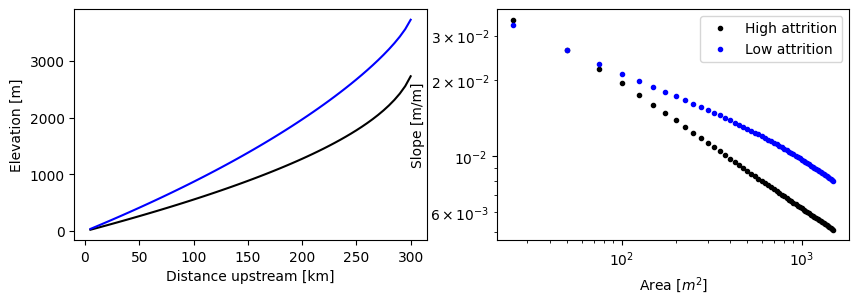

In [7]:
fig,ax = plt.subplots(1,2,figsize=(10,3))
plot_profile(ax, grid1, color='black',label='High attrition')
plot_profile(ax, grid2, color='blue', label= 'Low attrition')
plt.legend()
plt.show()

# Example 2: The role of bedrock abrasions
Lets initialize two similar 1D model grids to the previous example. However, in this case, the models differ in the rate at which the bedrock is eroded due to the action of sediment abrasion and in the sediment hardness.  In the first mode, `grid1`, the sediments are much softer than the bedrock, while in `grid2`, the sediments are much harder than the bedrock. 

In [9]:
# Run two EGBE models with two diffrent bedrock abrasion coeffs
grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid()
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid()

abrasion_coefficients1 = 10**-3
abrasion_coefficients2 = 10**-6

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                                abrasion_coefficients=abrasion_coefficients1,
                                                bedrock_abrasion_coefficient=abrasion_coefficients2)

                                                
grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                                abrasion_coefficients = abrasion_coefficients2,
                                                bedrock_abrasion_coefficient=abrasion_coefficients1)

SD already exists
SD already exists


In [10]:
uplift_rate = 10**-3
timestep=250
total_time = int(2e6)
for i in range(0,total_time,timestep):

    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,5e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
25.0 % completed
50.0 % completed
75.0 % completed
100.0 % completed


## Plot the results

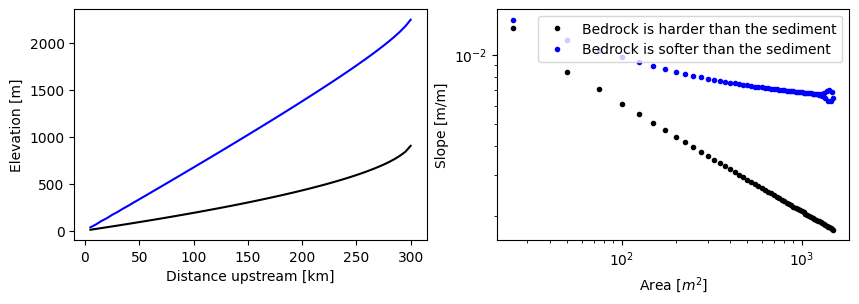

In [11]:
fig,ax = plt.subplots(1,2,figsize=(10,3))
plot_profile(ax, grid1, color='black',label= 'Bedrock is harder than the sediment')
plot_profile(ax, grid2, color='blue', label= 'Bedrock is softer than the sediment')
plt.legend()
plt.show()

# Example 3: Fixed-width vs. Dynamic width
This example explore river profile evolution under the two assumptions regarding channel width that are allowed in EGBE: fixed-width and dynamic-width. In fixed-width mode, channel width at any given position in the channel network is calculated using an empirical power-law relationship between width and bankfull discharge. In dynamic-width mode, channel width is assumed to maintain an equilibrium state with the bankfull flow conditions that are near the threshold for mobilizing the bed sediment. With this approach,  channel width depends on bankfull discharge, slope gradient, and median grain size. 

Two models will be intialized with the same parameters. However, the first will compute channel width based on the fixed-width assumption while the other follows the near-threshold principle using dynamic-width.

In [56]:
# Fix width vs. Dynamic width
grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid()
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid()

abrasion_coefficients1 = 10**(-4.3)
meansizes = 0.03

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                                meansizes=meansizes,
                                                abrasion_coefficients=abrasion_coefficients1)

grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                                abrasion_coefficients=abrasion_coefficients1,
                                                meansizes=meansizes,
                                                use_fixed_width=False)

SD already exists
SD already exists


In [57]:
uplift_rate = 10**-3
timestep=200
total_time = int(3e6)

for i in range(0,total_time,timestep):
    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,5e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
16.7 % completed
33.3 % completed
50.0 % completed
66.7 % completed
83.3 % completed
100.0 % completed


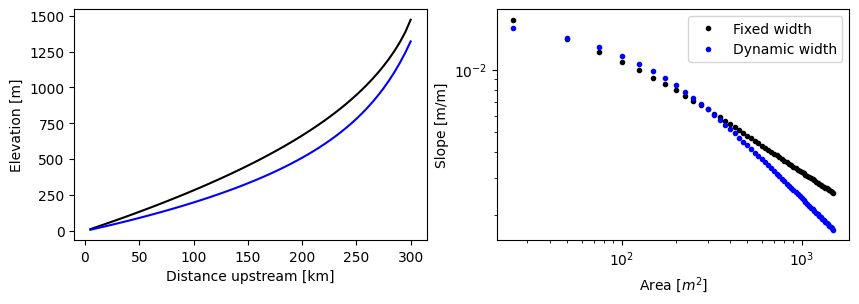

In [58]:
fig,ax = plt.subplots(1,2,figsize=(10,3))
plot_profile(ax, grid1, color='black', label='Fixed width')
plot_profile(ax, grid2, color='blue', label='Dynamic width')
plt.legend()
plt.show()

The river profile under dynamic-width is more concave relative to the fixed-width profile. We can explain this pattern by the downslope change in channel width and the shear stress exerted by the water on the river bed. 


EGBE stores these two variables, so let's plot them:

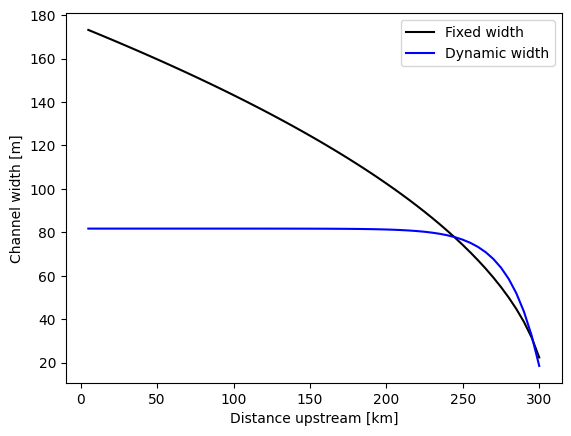

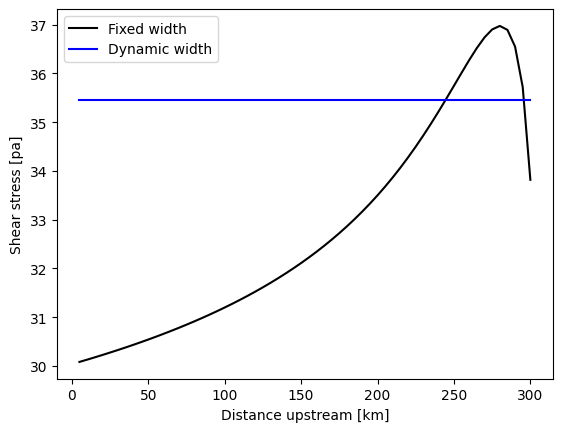

In [59]:
xvec  = grid1.node_y[grid1.core_nodes]/1000
plt.plot(xvec,eroder1._channel_width[grid1.core_nodes],color='black',label='Fixed width')
plt.plot(xvec,eroder2._channel_width[grid1.core_nodes],color='blue', label='Dynamic width')
plt.xlabel('Distance upstream [km]')
plt.ylabel('Channel width [m]')
plt.legend()
plt.show()

xvec  = grid1.node_y[grid1.core_nodes]/1000
plt.plot(xvec,eroder1._tau[grid1.core_nodes],color='black',label='Fixed width')
plt.plot(xvec,eroder2._tau[grid1.core_nodes],color='blue', label='Dynamic width')
plt.xlabel('Distance upstream [km]')
plt.ylabel('Shear stress [pa]')
plt.legend()
plt.show()


The river channel width is narrower under dynamic width in order to keep the bankfull shear stress constant (following the near-threshold principle). At a distance of ~75km from the channel head, near-trehsold stresses are higher than shear stresses under the fixed width assumption, which results in enhanced incision and lower topographic slope. 

Changes in concavity could affect the 2D structure and morphology of the river network. The next simulation will test that by running EGBE over a domain with 50 rows and 25 columns, while all  bottom nodes are set as open boundary. 

In [12]:
abrasion_coefficients1 = 10**(-4.3)
meansizes = 0.03

grid1, topo1, rock_elev1,  soil_depth1 = create_2d_grid(n_rows=50, n_cols=25)
grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                               meansizes=meansizes,
                                                abrasion_coefficients=abrasion_coefficients1,
                                               use_fixed_width=True)

grid2, topo2, rock_elev2,  soil_depth2 = create_2d_grid(n_rows=50, n_cols=25)
grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                               abrasion_coefficients=abrasion_coefficients1,
                                                meansizes=meansizes,
                                                use_fixed_width=False,)

SD already exists
SD already exists


In [13]:
uplift_rate = 10**-3
timestep=250
total_time = int(1.5e6)

for i in range(0,total_time,timestep):
    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,2.5e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
16.7 % completed
33.3 % completed
50.0 % completed
66.7 % completed
83.3 % completed
100.0 % completed


Using `imshow_grid` function we will generate two map-view topography figures

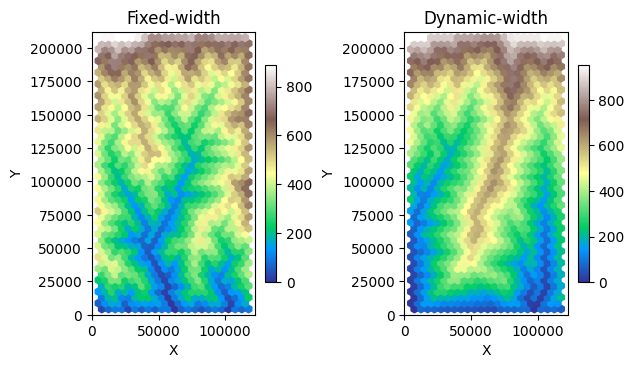

In [14]:
fig,ax = plt.subplots(1,2)
plt.axes(ax[0])
imshow_grid(grid1,'topographic__elevation',cmap='terrain', shrink=0.5)
ax[0].set_title('Fixed-width')
plt.axes(ax[1])
imshow_grid(grid2,'topographic__elevation',cmap='terrain', shrink=0.5)
ax[1].set_title('Dynamic-width')
plt.tight_layout()
plt.show()

To find and plot the channels topography in this case we will use the Landlab component `ChannelProfiler`. 

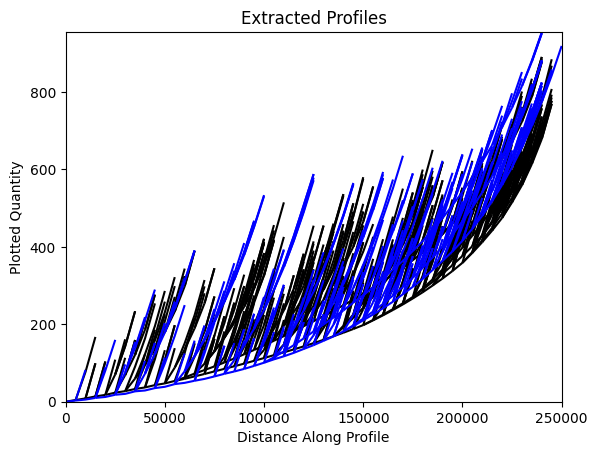

In [15]:
channel_threshold = 1e6
profiler1 = ChannelProfiler(
    grid1,
    number_of_watersheds=1,
    minimum_channel_threshold=channel_threshold,
    main_channel_only=False
)
profiler1.run_one_step()

profiler2 = ChannelProfiler(
    grid2,
    number_of_watersheds=1,
    minimum_channel_threshold=channel_threshold,
    main_channel_only=False
)
profiler2.run_one_step()

fig,ax =plt.subplots()
profiler1.plot_profiles(color='black', )
profiler2.plot_profiles(color='blue', )
plt.show()

Similar to the 1D example, this figure highlights that the dynamic-width river develops a more concave profile. Also, it shows that the dynamic-width landscape is associated with fewer tributaries, and is overall less incised.

# Example 4: Simulating river profile evolution with fine versus coarse landslide-derived sediments using EGBE and Bedrocklandslider
The Landlab BedrockLandslider (Hybrid Landscape evolution model) component computes stochastic deep-seated bedrock landsliding and landslide-derived sediment runout across two-dimensional model landscapes. To  simulates both continuous fluvial incision and sediment transport in a river associated with landslides, we will couple Bedrocklandslider with EGBE. 

## One cool application of EGBE and SoilGrading is that we can take into account the properties of the landslide grains. Here,  we will examine how the river evolves if the slide is associated with fine or coarse sediments. 

We begin by initializing two models. Their grids are associated with two sediment classes that differ in size: 1 cm and 7 cm, set by the variable `meansizes` of `SoilGrading`.  Also, in both models,  we assume the bedrock plucked into the fine fraction (1 cm) as set by the variable `bed_grains_proportions`.

In [64]:
n_rows = 200
n_cols = 3
spacing = 25
init_slope = 0.05
meansizes = [0.01, 0.07] # Two classes of diffrent size
grains_weight = [5000, 0]
bed_grains_proportions=[1,0] # Bedrock breaks only into the smaller class
phi = 0.4
sediment_density = 2650
runoff_rate=5
elev_jump = 150


grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid(n_rows = n_rows, init_slope=init_slope, spacing=spacing)
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid(n_rows = n_rows, init_slope=init_slope, spacing=spacing)

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                                bed_grains_proportions=bed_grains_proportions,
                                                meansizes=meansizes,
                                               init_hylands = True,
                                               threshold_slope=0.5,
                                               angle_int_frict=0.5,
                                                min_deposition_slope=0.2,
                                                runoff_rate=runoff_rate,
                                               grains_weight=grains_weight)

grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                                bed_grains_proportions=bed_grains_proportions,
                                                meansizes=meansizes,
                                                init_hylands = True,
                                               threshold_slope=0.5,
                                               angle_int_frict=0.5,
                                                min_deposition_slope=0.2,
                                                runoff_rate=runoff_rate,
                                               grains_weight=grains_weight)

SD already exists
hyland is on
SD already exists
hyland is on


At the middle of the river, we will now generate a "jump" in elevation, a knickpoint that will trigger landslide failure by BedrockLandslider

In [65]:
# Set boundaries and initial topography
grid1.at_node['bedrock__elevation'][grid1.core_nodes[50:]]+=elev_jump
grid2.at_node['bedrock__elevation'][grid2.core_nodes[50:]]+=elev_jump

grid1.at_node['topographic__elevation'][:] = grid1.at_node['bedrock__elevation'][:] + grid1.at_node['soil__depth'][:]
grid2.at_node['topographic__elevation'][:] = grid2.at_node['bedrock__elevation'][:] + grid2.at_node['soil__depth'][:]

Lets see how the topographic profile of these rivers looks like

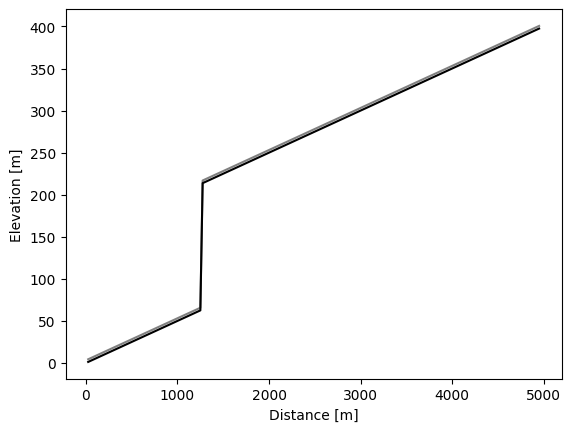

In [66]:
init_profile = np.copy(grid1.at_node['topographic__elevation'][grid1.core_nodes])
init_bedrock_profile = np.copy(grid1.at_node['bedrock__elevation'][grid1.core_nodes])
init_soil_profile = np.copy(grid1.at_node['soil__depth'][grid1.core_nodes])
xvec = np.cumsum(np.ones_like(init_profile)*spacing)
fig,ax = plt.subplots()
ax.plot(xvec, init_profile,color='gray')
ax.plot(xvec, init_bedrock_profile, color='black')
ax.set_xlabel('Distance [m]')
ax.set_ylabel('Elevation [m]')
plt.show()

To associate the landslide with diffrent properties of the grains, we will create additional fields `landslide_size_fraction1` and `landslide_size_fraction2`. These variable will let SoilGrading knows what are the sizes of the grains associate with the slide. For `grid1`,  we set the first size class fraction as `1` which means that the landslide is associate only with the smaller grain size (1 cm). For `grid2` we set the larger size fraction as `1` which means that the landslide is associate only with the coarser grains (7 cm). 

In [67]:
landslide_size_fraction1 = np.zeros_like(grid1.at_node['bed_grains__proportions'])
landslide_size_fraction1[:,0]=1

landslide_size_fraction2 = np.zeros_like(grid2.at_node['bed_grains__proportions'])
landslide_size_fraction2[:,1]=1

Let's run BedrockLandslider 50 years forward.
As the river is associated with an unstable knickpoint, landslides will be initiated by BedrockLandslider and their sediments will be deposited downslope. We will use `SoilGrading` procedure `update_mass_based_on_outsource_dz` to update the `grains__weight` field according to the the landslide deposited and the grain size distribution we created.

In [26]:
for _ in range(50):
    fa1.run_one_step()
    hy1.run_one_step(dt=1)
    sg1.update_mass_based_on_outsource_dz(proportions=landslide_size_fraction1)
    
    
    fa2.run_one_step()
    hy2.run_one_step(dt=1)
    sg2.update_mass_based_on_outsource_dz(proportions=landslide_size_fraction2)

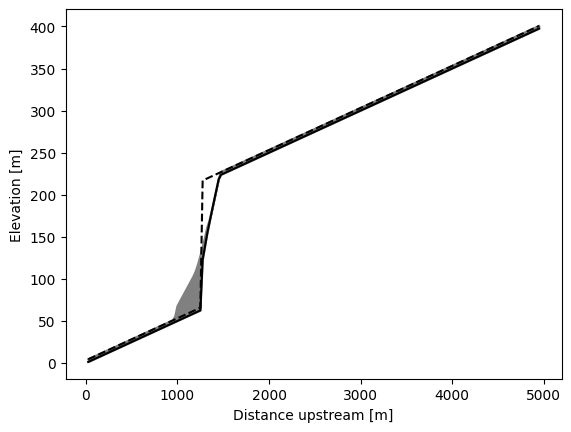

In [27]:
xspace = np.sqrt(grid1.area_of_cell)
xvec = np.cumsum(np.ones_like([grid1.core_nodes])*xspace)

fig,ax = plt.subplots()
ax.plot(xvec,
        grid1.at_node['topographic__elevation'][grid1.core_nodes],
        color='gray')
ax.plot(xvec,
        grid1.at_node['bedrock__elevation'][grid1.core_nodes],
        color='black')

ax.fill_between(xvec, grid1.at_node['topographic__elevation'][grid1.core_nodes], 
                grid1.at_node['bedrock__elevation'][grid1.core_nodes],
               color='gray')

ax.plot(xvec,
        init_profile,color='black',
        ls='--',
        label='Initial profile')

ax.set_xlabel('Distance upstream [m]')
ax.set_ylabel('Elevation [m]')
plt.show()

We will now let EGBE evolove the river profiles over 1200 years and interact with the landslide deposits

In [28]:
timestep=100
n_steps = 12
for i in range(n_steps):
    fa1.run_one_step()
    eroder1.run_one_step(timestep)

    fa2.run_one_step()
    eroder2.run_one_step(timestep)
    if np.mod(i,4)==0:
        print(np.round((i/n_steps)*100,1), '% completed')

0.0 % completed
33.3 % completed
66.7 % completed


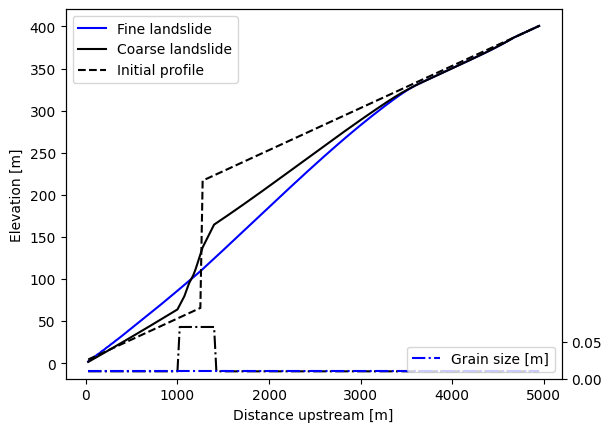

In [45]:
xspace = np.sqrt(grid1.area_of_cell)
xvec = np.cumsum(np.ones_like([grid1.core_nodes])*xspace)

fig,ax = plt.subplots()
ax.plot(xvec,
        grid1.at_node['topographic__elevation'][grid1.core_nodes],
        color='blue',
        label='Fine landslide')
ax.plot(xvec,
        grid2.at_node['topographic__elevation'][grid2.core_nodes],
        color='black',
        label='Coarse landslide')
ax.plot(xvec,
        init_profile,color='black',
        ls='--',
        label='Initial profile')
plt.legend()

# ax.set_xlim([0,3500])
# ax.set_ylim([0,350])

ax2 = ax.twinx()
ax2.plot(xvec, 
         grid2.at_node['median_size__weight'][grid2.core_nodes],
         color='black',ls='-.')

ax2.plot(xvec, 
         grid1.at_node['median_size__weight'][grid1.core_nodes],
        color='blue',ls='-.',
        label='Grain size [m]')
plt.legend(loc='lower right')

ax2.set_yticks([0.0, 0.05])
ax2.set_ylim([0,0.5])
ax.set_xlabel('Distance upstream [m]')
ax.set_ylabel('Elevation [m]')
plt.show()

Differences in the size of the landslide deposits impact the erosion rate and morphology of the rivers. While the coarser landslide slows down incision, the fine landslide washed away and is not distinctly shown in the river profile. 

In [10]:
np.divide(100,0)

/var/folders/k2/skpg2jsd2ms7rfthlmp9nhg00000gn/T/ipykernel_29270/1301769774.py:1: RuntimeWarning: divide by zero encountered in divide
  np.divide(100,0)


np.float64(inf)

# Example 5: Simulating river profile evolution with course-grained landslide material and fine-grained bed material

One of the advantages of EGBE is that it can introduce new grain sizes via some external process. A great example of this would be a landslide that deposits coarse-grained material in an otherwise fine grained system.

We'll start by importing existing topography that was run to a quasi-steady state.

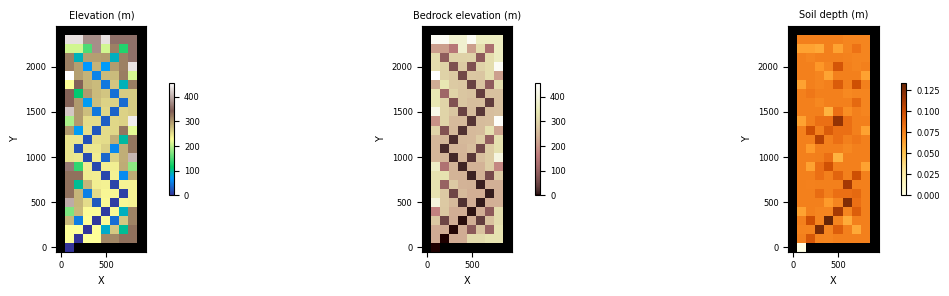

In [196]:
with open('egbe_ls_2d_eq.pkl', 'rb') as f:
    grid = pickle.load(f)

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
plt.axes(ax[0]); imshow_grid(grid, 'topographic__elevation', cmap='terrain', shrink=0.5)
ax[0].set_title('Elevation (m)')
plt.axes(ax[1]); imshow_grid(grid, 'bedrock__elevation', shrink=0.5)
ax[1].set_title('Bedrock elevation (m)')
plt.axes(ax[2]); imshow_grid(grid, 'soil__depth', cmap='YlOrBr', shrink=0.5)
ax[2].set_title('Soil depth (m)')
plt.tight_layout()
plt.show()

First, we need to instantiate all correct components. The setup below instantiates **PriorityFloodFlowRouter**, **SoilGrading**, and **ExtendedGravelBedrockEroder** in the same way that creates the landscape above. The new thing is the **BedrockLandslider**.

In [197]:
bed_grains_proportions = [1, 0]
sediment_density       = 2650

fr = PriorityFloodFlowRouter(
    grid,
    surface              = 'topographic__elevation',
    runoff_rate          = 13,
    flow_metric          = 'D8',
    depression_handler   = 'fill',
    accumulate_flow      = True,
    separate_hill_flow   = True,
    accumulate_flow_hill = True,
)

grid.at_node['grains_classes__size'][:] = 1.0

sg = SoilGrading(
    grid,
    meansizes    = [0.01, 0.07],
    grains_weight= [0, 0],
    phi          = 0.35,
    soil_density = sediment_density,
)
sg.update_bed_grains_proportions(proportions=bed_grains_proportions)

eroder = ExtendedGravelBedrockEroder(
    grid,
    intermittency_factor         = 0.01,
    depth_decay_scale            = 1,
    plucking_coefficient         = 1e-2, 
    abrasion_coefficients        = 0.005,
    bedrock_abrasion_coefficient = 5e-4, 
    fractions_from_plucking      = bed_grains_proportions,
    rho_sed                      = sediment_density,
    rho_water                    = 1000,
    use_fixed_width              = True,
    fixed_width_coeff            = 0.002,
    fixed_width_expt             = 0.5,
    mannings_n                   = 0.05,
    tau_star_c_median            = 0.045,
    alpha                        = 0.68,
    tau_c_bedrock                = 1,
    d_min                        = 0.1,
    plucking_by_tools_flag       = False,
)


 el1EI


C:\Users\susan\landlab\src\landlab\graph\sort\sort.py:724: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


We first need to run for a few years to generate our landslide. The below setup will run with a landslide return time of 10 years. With the probabilistic landsliding characteristic of the BedrockLandslider this results in a landslide in year 40.

In [198]:
ls = BedrockLandslider(
    grid,
    angle_int_frict          = 0.85,      
    threshold_slope          = 0.85,      # m/m
    cohesion_eff             = 1e8,       # Pa
    landslides_return_time   = 10,        # years (1 = every timestep)
    landslides_on_boundary_nodes = False,
    phi                      = 0.35,
    fraction_fines_LS        = 0.90,
)

We need a couple of functions to help us print useful figures. These are a bit extensive, so the cell has been collapsed. It should still run if you run the cell.

In [199]:
# functions

def plot_profile_with_soil(grid, profiler, ax):
    brown_color = [205/255, 133/255, 63/255]

    riv_nodes    = profiler.nodes
    dist_atNodes = profiler.distance_along_profile[0]

    el = grid.at_node['topographic__elevation'][riv_nodes].ravel()
    sd = grid.at_node['soil__depth'][riv_nodes].ravel()
    br = el - sd

    min_elevation = min(np.min(el), np.min(br), 0)
    el_relief = el - min_elevation
    br_relief = br - min_elevation

    dist = (max(dist_atNodes) - dist_atNodes) * 1e-3  # km, headwater → mouth

    ax2 = ax.twinx()
    ax.fill_between(dist, br_relief, 0,         color='grey',      label='bedrock')
    ax.fill_between(dist, el_relief, br_relief, color=brown_color, label='soil')
    ax.plot(dist, br_relief, color='k',     linewidth=0.8, zorder=3)
    ax.plot(dist, el_relief, color='brown', linewidth=1.0, zorder=4)
    ax2.plot(dist, sd, color='orange', linewidth=0.8, label='soil depth')

    ax.set_xlabel('Distance Along Profile (km)')
    ax.set_ylabel('Relief (m)')
    ax.set_ylim(0, np.max(el_relief) * 1.1)
    ax2.set_ylabel('Soil thickness (m)')
    ax2.set_ylim(0, np.nanmax(sd) * 1.4)
    ax.set_title('Channel Profile')

    channel_nodes = (np.concatenate(riv_nodes)
                     if isinstance(riv_nodes, list)
                     else riv_nodes.ravel())
    return channel_nodes, dist

def plot_landslide_erosion_deposition(grid, ax=None, figsize=(8, 6)):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    nrows = grid.number_of_node_rows
    ncols = grid.number_of_node_columns
    extent = [0, ncols * grid.dx, 0, nrows * grid.dy]

    topo = grid.at_node["topographic__elevation"].reshape(nrows, ncols)
    ax.imshow(topo, cmap="gray", origin="lower", extent=extent)

    # Check fields exist before accessing
    has_erosion_field = "landslide__erosion" in grid.at_node
    has_deposition_field = "landslide__deposition" in grid.at_node

    if not has_erosion_field and not has_deposition_field:
        ax.set_title("Landslide Erosion & Deposition\n(no landslide fields on grid)")
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        return ax

    divider = make_axes_locatable(ax)

    if has_erosion_field:
        erosion = grid.at_node["landslide__erosion"].copy()
        if np.any(erosion > 0):
            erosion[erosion <= 0] = np.nan
            drape1 = np.sqrt(erosion).reshape(nrows, ncols)
            im1 = ax.imshow(drape1, cmap="hot_r", origin="lower",
                            extent=extent, alpha=0.7)
            cax1 = divider.append_axes("right", size="5%", pad=0.05)
            plt.colorbar(im1, cax=cax1, label=r"$\sqrt{LS_{erosion}}$")

    if has_deposition_field:
        deposition = grid.at_node["landslide__deposition"].copy()
        if np.any(deposition > 0):
            deposition[deposition <= 0] = np.nan
            drape2 = np.log10(deposition).reshape(nrows, ncols)
            im2 = ax.imshow(drape2, cmap="winter_r", origin="lower",
                            extent=extent, alpha=0.7)
            cax2 = divider.append_axes("right", size="5%", pad=0.6)
            plt.colorbar(im2, cax=cax2, label=r"$\log^{10} LS_{deposition}$")

    ax.set_title("Landslide Erosion & Deposition")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    return ax

def plot_channel_grains(grain_history, meansizes_m, cell_area, xlim=None, figsize=(14, 4), plot_cumm_landslide=True): #SMM: added cell_area to fix some unit conversions
    """
    Plot grain mass along the channel profile for each stored snapshot.

    grain_history    : list of dicts {'time', 'grains' (n_nodes x n_classes), 'dists_km'}
    meansizes_m : e.g. [0.03, 0.07]
    xlim         : (min_km, max_km) to zoom in — None shows full profile
    figsize      : figure size per row
    """
    colors  = ['#FFA500', '#4472C4']
    bar_w   = 0.035   # km — shrink if nodes are dense, grow if sparse

    fig, axes = plt.subplots(len(grain_history), 1, figsize=(figsize[0], figsize[1] * len(grain_history)), squeeze = False)

    for t_idx, record, in enumerate(grain_history):
        ax = axes[t_idx, 0]
        dists = record['dists_km']
        grains = record['grains']
        n_cls = grains.shape[1] if grains.ndim > 1 else 1
        offsets = np.linspace(-(n_cls - 1) * bar_w / 2,
                               (n_cls - 1) * bar_w / 2, n_cls)
        for c in range(n_cls):
            mass = (grains[:, c] if grains.ndim > 1 else grains) * cell_area # SMM: needed to add the * cell_area for unit things
            label = f'{meansizes_m[c]} m'
            ax.bar(dists + offsets[c], mass, width=bar_w*0.85, color=colors[c%len(colors)], label=label, alpha = 0.85)
            
        if plot_cumm_landslide == True:
            if 'grains_ls' in record:
                grains_ls = record['grains_ls']
                for c in range(n_cls):
                    mass_ls = (grains_ls[:, c] if grains_ls.ndim > 1 else grains_ls) # SMM: again correction for correct units
                    ax.bar(dists + offsets[c], mass_ls, width=bar_w*0.85, color = colors[c % len(colors)], alpha=0.4, hatch='///', label=f'{meansizes_m[c]} m (landslide)')
        else:
            pass
            
        ax.set_title(f't = {record["time"]:,} yr')
        ax.set_xlabel('Distance Along Channel (km)')
        ax.set_ylabel('Grain mass (kg)') # SMM: need to change this to kg/m^2 to match what grains__weight actually is
        if xlim is not None:
            ax.set_xlim(xlim)
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
def plot_3d_drape(grid, drape_field, 
                  cmap='YlOrBr', 
                  log_scale=True,
                  elev=30, azim=225,
                  z_exag=1.0,
                  figsize=(10, 8),
                  title=None,
                  colorbar_label=None):
    """
    3D surface plot of a Landlab grid with a draped field as colour.
    
    Parameters
    ----------
    grid : RasterModelGrid
    drape_field : str or np.ndarray
        Field name (str) or node array. E.g. 'bedload__sediment_flux'.
    cmap : str
        Matplotlib colormap name.
    log_scale : bool
        Log-normalise the colour drape (good for flux fields spanning orders of magnitude).
    elev, azim : float
        Viewing elevation and azimuth angles in degrees.
    z_exag : float
        Vertical exaggeration factor.
    """
    nrows, ncols = grid.shape

    # --- Reshape fields to 2D grid ---
    elev_2d = grid.at_node['topographic__elevation'].reshape(nrows, ncols)
    
    if isinstance(drape_field, str):
        drape = grid.at_node[drape_field].reshape(nrows, ncols)
    else:
        drape = drape_field.reshape(nrows, ncols)

    x = grid.x_of_node.reshape(nrows, ncols) / 1000  # → km
    y = grid.y_of_node.reshape(nrows, ncols) / 1000

    # --- Colour normalisation ---
    valid = drape[drape > 0]
    if log_scale and len(valid) > 0:
        norm = mcolors.LogNorm(vmin=valid.min(), vmax=valid.max())
    else:
        norm = mcolors.Normalize(vmin=drape.min(), vmax=drape.max())

    cmap_obj = plt.get_cmap(cmap)
    
    # plot_surface needs face colours: shape is (nrows-1, ncols-1)
    # Average drape over each cell's 4 corners
    drape_face = (drape[:-1, :-1] + drape[1:, :-1] + 
                  drape[:-1, 1:]  + drape[1:, 1:]) / 4
    facecolors = cmap_obj(norm(drape_face))

    # --- Plot ---
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(
        x, y, elev_2d * z_exag,
        facecolors=facecolors,
        rstride=1, cstride=1,
        linewidth=0,
        antialiased=True,
        shade=False,   # disable matplotlib shading — the drape IS the colour
    )

    # Viewing angle
    ax.view_init(elev=elev, azim=azim)

    # Clean up panes to match the white-box look in the image
    ax.set_box_aspect([
        (x.max() - x.min()),
        (y.max() - y.min()),
        (elev_2d.max() - elev_2d.min()) * z_exag * 0.3  # compress z visually
    ])
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zticks([])   # hide z ticks like the reference image

    if title:
        ax.set_title(title)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.1)
    if colorbar_label:
        cb.set_label(colorbar_label)

    plt.tight_layout()
    return fig, ax


def plot_3d_landslide_extended(grid,
                               profiler,
                               grains__weight,         # node array, shape (n_nodes, n_classes)
                               grain_sizes_m,         # list of grain sizes in m, e.g. [0.03, 0.07]
                               landslide_grains__weight,  # node array, shape (n_nodes, n_classes)
                               elapsed_time=None,
                               elev=35, azim=225,
                               z_exag=3.0,
                               figsize=(20, 16),       # taller to fit 4 panels
                               log_scale=True,
                               erosion_min=None,
                               deposition_min=None,
                               n_ticks=4,
                               topo_cmap='terrain',
                               topo_base_color=None,
                               plot_cumm_landslide=False,
                               save_fig=False,
                               fixed_ranges=None,
                               hillshade=True,
                               hillshade_azimuth=315,
                               hillshade_altitude=45,
                               hillshade_intensity=0.6,
                               plot_channel_profs_on_3d=False,
                               single_ls_colorbar=False,
                               ls_diverging_cmap='BrBG',#cm.managua,
                               soil_cmap='YlOrBr',
                               panel_zoom=1.35
                              ):
    """
    Four-panel figure:
    - Top left:  3D topography
    - Top right: 3D overlay — landslide erosion & deposition (draped on topography),
                 OR sediment depth on channel nodes only, if no landslide activity
                 is present this timestep (see "Right-panel overlay logic" below)
    - Middle:    channel longitudinal profile (elevation + sediment thickness)
    - Bottom:    grain size distribution along channel

    X axis on both longitudinal plots runs downstream (left) to upstream (right),
    per `profiler.distance_along_profile`.

    Right-panel overlay logic
    --------------------------
    The top-right 3D panel automatically switches between three modes, in this
    priority order:
    1. No landslide activity this timestep (no erosion or deposition above
       `erosion_min`/`deposition_min` anywhere on the grid) → drapes
       `soil__depth`, masked to show only on channel faces (any face touching
       a `profiler` channel node), with hillshaded terrain showing through
       everywhere else.
    2. Landslide activity present AND `single_ls_colorbar=True` → drapes a
       single signed field (erosion negative, deposition positive), compressed
       with a signed square-root transform and colored with a diverging
       colormap (`ls_diverging_cmap`) centered at zero. Only faces with
       nonzero activity are opaque; the colorbar itself is labeled in true
       physical units (m) even though color is mapped in sqrt-space, and
       ticks are anchored to include exactly zero and both true extremes
       (-vmax_eros, vmax_depo) regardless of `n_ticks`.
    3. Landslide activity present AND `single_ls_colorbar=False` → drapes
       erosion and deposition as two independently-colored, independently
       thresholded overlays (`ero_colorbar`, `depo_colorbar`), each with its
       own colorbar.

    Parameters
    ----------
    grid : RasterModelGrid
    profiler : ChannelProfiler - Already-run ChannelProfiler instance; used both for the longitudinal profile panels and to build the channel mask for the soil-depth overlay.
    grains__weight : np.ndarray, shape (n_nodes, n_classes) - Grain mass per unit area at each node (kg/m²).
    grain_sizes_m : list of float - Grain size for each class in m.
    landslide_grains__weight : np.ndarray, shape (n_nodes, n_classes) - Landslide-derived grain mass at each node (kg/m²).
    elapsed_time : float, optional - Model time in years, shown in the figure title.
    elev, azim : float - 3D viewing angle in degrees.
    z_exag : float - Vertical exaggeration factor for the 3D surfaces.
    figsize : tuple - Overall figure size. Figure is designed to be comfortably wide
        (the two 3D panels sit side by side with no overlap) — a wide/short aspect
        ratio (e.g. (16, 10) or wider) works well in a notebook.
    log_scale : bool - Log-normalize erosion/deposition color mapping when `single_ls_colorbar=False`.
    erosion_min, deposition_min : float, optional - Minimum magnitude (m) to treat as active rather than noise. Defaults to the 10th percentile of nonzero values for each field.
    n_ticks : int - Approximate number of colorbar ticks. For the diverging landslide colorbar, ticks are currently split as 4 negative / 3 positive (hardcoded) rather than derived from `n_ticks`; the elevation and soil-depth colorbars use `n_ticks` directly via `np.linspace`.
    topo_cmap : str - Colormap for the topography panel and, when `topo_base_color` is None, the underlying terrain shading in the right panel.
    topo_base_color : str or None - If set, the right panel's base terrain is a flat color instead of `topo_cmap`-mapped elevation (useful for isolating the overlay).
    plot_cumm_landslide : bool - If True, overlay hatched bars in the grain-mass panel showing the landslide-derived portion of each grain class.
    save_fig : bool - If True, save to '../data/figures/coarse_slides/'.
    fixed_ranges : dict, optional - Static axis/colorbar ranges to keep consistent across frames (e.g. for animations). Recognized keys: 'elev', 'erosion', 'deposition', 'relief', 'soil', 'grain_mass'.
    hillshade : bool - Blend a computed hillshade into both 3D panels' base terrain.
    hillshade_azimuth, hillshade_altitude, hillshade_intensity : float - Hillshade light source direction, angle, and blend strength.
    plot_channel_profs_on_3d : bool - If True, draw the channel network as a black line on both 3D panels.
    single_ls_colorbar : bool - Selects overlay mode 2 vs. mode 3 above, when landslide activity is - present. Has no effect when there's no landslide activity (mode 1 - always applies in that case).
    ls_diverging_cmap : Colormap - Diverging colormap used for the single-colorbar landslide overlay (mode 2). Independent of `single_ls_colorbar`'s True/False toggle.
    soil_cmap : str - Colormap for the channel-masked sediment-depth overlay (mode 1).
    panel_zoom : float - Camera zoom applied to both 3D panels via `Axes3D.set_box_aspect(..., zoom=panel_zoom)`
        (matplotlib >= 3.6). Values > 1 pull the camera in, shrinking the empty
        margin around the surface so the landscape fills more of its panel;
        1.0 is matplotlib's default framing. Increase toward ~1.5-1.8 for a
        tighter crop; watch for the surface clipping at panel edges if pushed
        too far, especially combined with a large `z_exag`.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : tuple of Axes
        (ax_topo, ax_ls, ax_prof, ax_grain)
    """
    nrows, ncols = grid.shape
    cell_area = grid.dx * grid.dy

    elev_2d    = grid.at_node['topographic__elevation'].reshape(nrows, ncols)
    erosion    = grid.at_node['landslide__erosion'].reshape(nrows, ncols).copy()
    deposition = grid.at_node['landslide__deposition'].reshape(nrows, ncols).copy()

    if erosion_min is None:
        erosion_min = np.percentile(erosion[erosion > 0], 10) if (erosion > 0).any() else 1e-3
    if deposition_min is None:
        deposition_min = np.percentile(deposition[deposition > 0], 10) if (deposition > 0).any() else 1e-3

    erosion[erosion < erosion_min]          = 0
    deposition[deposition < deposition_min] = 0

    # --- Extract channel profile data ---
    outlet_id = list(profiler.data_structure.keys())[0]
    seg_id    = list(profiler.data_structure[outlet_id].keys())[0]
    segment   = profiler.data_structure[outlet_id][seg_id]
    riv_nodes = segment['ids']

    x = grid.x_of_node.reshape(nrows, ncols)
    y = grid.y_of_node.reshape(nrows, ncols)

    # --- Colour helpers ---
    def make_facecolors(data_2d, cmap_name, log_scale, alpha_active=0.9):
        face = (data_2d[:-1, :-1] + data_2d[1:, :-1] +
                data_2d[:-1, 1:]  + data_2d[1:, 1:]) / 4
        active = face > 0
        rgba = np.zeros((*face.shape, 4))
        if active.any():
            vals = face[active]
            norm = mcolors.LogNorm(vmin=vals.min(), vmax=vals.max()) if log_scale \
                   else mcolors.Normalize(vmin=0, vmax=vals.max())
            rgba[active] = plt.get_cmap(cmap_name)(norm(vals))
            rgba[active, 3] = alpha_active
        return rgba

    def alpha_composite(base, overlay):
        alpha = overlay[..., 3:4]
        return overlay * alpha + base * (1 - alpha)

    def apply_view(ax):
        ax.view_init(elev=elev, azim=azim)
        x_range = x.max() - x.min()
        y_range = y.max() - y.min()
        z_range = (elev_2d.max() - elev_2d.min()) * z_exag
        # zoom > 1 pulls the camera in, shrinking the empty margin matplotlib
        # otherwise leaves around the surface inside its axes box
        ax.set_box_aspect([x_range, y_range, z_range * 0.3], zoom=panel_zoom)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_zticks([])
        ax.grid(False)
        ax.xaxis.pane.set_edgecolor('none')
        ax.yaxis.pane.set_edgecolor('none')
        ax.zaxis.pane.set_edgecolor('none')
        ax.set_axis_off()

    def compute_hillshade(elev_2d, dx, azimuth=315, altitude=45):
        """
        Compute hillshade as a 2D array (0-1) from elevation.
        azimuth: light source direction in degrees (315 = NW)
        altitude: light source angle above horizon in degrees
        """
        # Convert angles to radians
        az  = np.deg2rad(360 - azimuth + 90)  # convert to math convention
        alt = np.deg2rad(altitude)

        # Compute slope and aspect from elevation gradients
        dy_elev, dx_elev = np.gradient(elev_2d, dx)
        slope  = np.arctan(np.sqrt(dx_elev**2 + dy_elev**2))
        aspect = np.arctan2(-dy_elev, dx_elev)

        # Hillshade formula
        shade = (np.sin(alt) * np.cos(slope) +
                 np.cos(alt) * np.sin(slope) * np.cos(az - aspect))
        shade = np.clip(shade, 0, 1)
        return shade

    def apply_hillshade(rgba, shade_face, intensity=0.7):
        """intensity controls how strong the shading effect is (0=none, 1=full)"""
        out = rgba.copy()
        out[..., :3] *= (1 - intensity + intensity * shade_face[..., np.newaxis])
        return np.clip(out, 0, 1)


    terrain_face = (elev_2d[:-1, :-1] + elev_2d[1:, :-1] +
                    elev_2d[:-1, 1:]  + elev_2d[1:, 1:]) / 4

    e_vmin, e_vmax = fixed_ranges['elev'] if fixed_ranges and 'elev' in fixed_ranges \
                     else (elev_2d.min(), elev_2d.max())

    topo_rgba = plt.get_cmap(topo_cmap)(mcolors.Normalize(vmin=e_vmin, vmax=e_vmax)(terrain_face))

    # setting up base color if just want hillshade
    if topo_base_color is not None:
        base_rgba = mcolors.to_rgba(topo_base_color)
        terrain_rgba = np.ones((*terrain_face.shape, 4)) * np.array(base_rgba)
    else:
        terrain_rgba = plt.get_cmap('Greys_r')(mcolors.Normalize(vmin=e_vmin, vmax=e_vmax)(terrain_face))

    if hillshade:
        shade = compute_hillshade(elev_2d, grid.dx, hillshade_azimuth, hillshade_altitude)
        shade_face = (shade[:-1, :-1] + shade[1:, :-1] +
                      shade[:-1, 1:]  + shade[1:, 1:]) / 4
        # blend hilshade on topo
        terrain_rgba = apply_hillshade(terrain_rgba, shade_face, hillshade_intensity)
        topo_rgba = apply_hillshade(topo_rgba, shade_face, hillshade_intensity)


    # Compute once, used by both surface colours and colorbar
    vmax_eros = fixed_ranges['erosion'][1]    if fixed_ranges and 'erosion'    in fixed_ranges else erosion.max()
    vmax_depo = fixed_ranges['deposition'][1] if fixed_ranges and 'deposition' in fixed_ranges else deposition.max()

    # setting up colorbars
    ls_colorbar = ls_diverging_cmap # single colorbar
    ero_colorbar = 'autumn_r'#'gnuplot_r'#'Reds'#cm.lajolla_r # erosion colorbar
    depo_colorbar = 'winter_r'#cm.lapaz_r # deposition colorbar

    soil_2d = grid.at_node['soil__depth'].reshape(nrows, ncols)
    has_landslide_activity = (erosion >0).any() or (deposition>0).any()

    channel_mask = np.zeros(grid.number_of_nodes, dtype=bool)
    channel_mask[riv_nodes] = True
    channel_mask_2d = channel_mask.reshape(nrows, ncols)

    # defining channel nodes as those if any of 4 corner nodes iss a channel node
    face_on_channel = (channel_mask_2d[:-1, :-1] | channel_mask_2d[1:, :-1] | channel_mask_2d[:-1, 1:] | channel_mask_2d[1:, 1:])

    if not has_landslide_activity:
        soil_face = (soil_2d[:-1, :-1] + soil_2d[1:, :-1] + soil_2d[:-1, 1:]  + soil_2d[1:, 1:]) / 4
        if fixed_ranges and 'soil' in fixed_ranges:
            s_vmin_map, s_vmax_map = fixed_ranges['soil']
        else:
            s_vmin_map, s_vmax_map = (0, soil_face.max())
        norm_soil = mcolors.Normalize(vmin= -s_vmin_map, vmax = s_vmax_map)
        soil_face_rgba = plt.get_cmap(soil_cmap)(norm_soil(soil_face))
        soil_face_rgba[..., 3] = 0.0 # transparent everywhere
        soil_face_rgba[face_on_channel, 3] = 0.85 # opaque only on channel faces
        landslide_rgba = alpha_composite(terrain_rgba, soil_face_rgba)

    elif single_ls_colorbar:
        ero_depo_sqrt = np.zeros_like(erosion)
        ero_depo_sqrt[erosion>0] = -np.sqrt(erosion[erosion>0])
        ero_depo_sqrt[deposition > 0] = np.sqrt(deposition[deposition>0])

        # converting from nodes to cells for plotting
        face = (ero_depo_sqrt[:-1, :-1] + ero_depo_sqrt[1:, :-1] + ero_depo_sqrt[:-1, 1:] + ero_depo_sqrt[1:, 1:]) / 4

        # making it symetric in sqrt space
        vmax_sqrt = max(np.sqrt(vmax_eros), np.sqrt(vmax_depo))
        norm_surface = mcolors.TwoSlopeNorm(           #vmin=-vmax_sqrt, vcenter=0, vmax=vmax_sqrt)
            vmin=-np.sqrt(vmax_eros), vcenter=0, vmax=np.sqrt(vmax_depo))
        landslide_face_rgba = plt.get_cmap(ls_colorbar)(norm_surface(face))

        # adding transparency where there aren't slides
        active = np.abs(face) > 0
        landslide_face_rgba[~active, 3] = 0.0
        landslide_face_rgba[active, 3] = 0.9
        landslide_rgba = alpha_composite(terrain_rgba, landslide_face_rgba)

    else:
        erosion_rgba    = make_facecolors(erosion,    ero_colorbar,    log_scale)
        deposition_rgba = make_facecolors(deposition, depo_colorbar, log_scale)
        landslide_rgba  = alpha_composite(alpha_composite(terrain_rgba, erosion_rgba), deposition_rgba)

    # --- Figure layout ---
    fig = plt.figure(figsize=figsize)
    if elapsed_time is not None:
        fig.suptitle(f't = {elapsed_time:.0f} yr', fontsize=12, y=0.98)

    # Top row: two 3D axes, side by side with no overlap and fully inside the
    # figure (left+width <= 1.0, bottom+height <= 1.0). Narrow side margins
    # are reserved for the colorbars that sit just outside each panel.
    TOP_BOTTOM   = 0.38
    TOP_HEIGHT   = 0.58           # top edge at 0.96 — stays inside the figure
    LEFT_MARGIN  = 0.045          # slim room for the elevation colorbar (label/ticks need a little breathing room)
    RIGHT_MARGIN = 0.105          # room for the right-panel colorbar(s) — sized for the "two separate colorbars" mode, which needs two bars + two labels side by side
    MID_GAP      = 0.020          # gap between the two 3D panels
    PANEL_WIDTH  = (1.0 - LEFT_MARGIN - RIGHT_MARGIN - MID_GAP) / 2
    ax_topo = fig.add_axes([LEFT_MARGIN, TOP_BOTTOM, PANEL_WIDTH, TOP_HEIGHT], projection='3d')
    ax_ls   = fig.add_axes([LEFT_MARGIN + PANEL_WIDTH + MID_GAP, TOP_BOTTOM, PANEL_WIDTH, TOP_HEIGHT], projection='3d')
    ax_topo.set_proj_type('ortho')
    ax_ls.set_proj_type('ortho')

    ax_topo.plot_surface(x, y, elev_2d * z_exag, facecolors=topo_rgba,
                         rstride=1, cstride=1, linewidth=0, antialiased=True, shade=False)
    # setting background transparent
    ax_topo.xaxis.pane.set_alpha(0.0)
    ax_topo.yaxis.pane.set_alpha(0.0)
    ax_topo.zaxis.pane.set_alpha(0.0)

    ax_ls.xaxis.pane.set_alpha(0.0)
    ax_ls.yaxis.pane.set_alpha(0.0)
    ax_ls.zaxis.pane.set_alpha(0.0)

    #ax_topo.set_title('Topography', pad=10)
    apply_view(ax_topo)

    ax_ls.plot_surface(x, y, elev_2d * z_exag, facecolors=landslide_rgba,
                       rstride=1, cstride=1, linewidth=0, antialiased=True, shade=False)
    #ax_ls.set_title('Landslide erosion & deposition', pad=10)
    apply_view(ax_ls)

    # --- Colorbars for 3D panels ---
    # Elevation colorbar sits in the left margin, left of ax_topo.
    cax_topo_x = LEFT_MARGIN * 0.25
    cax_topo_w = LEFT_MARGIN * 0.3
    # Right-panel colorbar(s) sit in the right margin, right of ax_ls.
    ax_ls_right = LEFT_MARGIN + 2 * PANEL_WIDTH + MID_GAP
    right_margin = 1.0 - ax_ls_right
    cax_right_w  = right_margin * 0.22

    topo_norm = mcolors.Normalize(vmin=e_vmin, vmax=e_vmax)
    topo_sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(topo_cmap), norm=topo_norm)
    topo_sm.set_array([])
    cax_topo = fig.add_axes([cax_topo_x, 0.55, cax_topo_w, 0.30])
    cb_topo = fig.colorbar(topo_sm, cax=cax_topo)
    cax_topo.set_title('Elevation\n[m]', fontsize=7, pad=4)
    topo_ticks = np.linspace(elev_2d.min(), elev_2d.max(), n_ticks)
    cb_topo.locator   = ticker.FixedLocator(topo_ticks)
    cb_topo.formatter = ticker.FixedFormatter([f'{v:.0f}' for v in topo_ticks])
    cb_topo.update_ticks()

    if not has_landslide_activity:
        soil_norm = mcolors.Normalize(vmin=s_vmin_map, vmax=s_vmax_map)
        sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(soil_cmap), norm=soil_norm)
        sm.set_array([])
        cax = fig.add_axes([ax_ls_right + right_margin * 0.35, 0.55, cax_right_w, 0.30])
        cb = fig.colorbar(sm, cax=cax)
        cax.set_title('Sediment depth\n[m]', fontsize=7, pad=4)
        tick_vals = np.linspace(s_vmin_map, s_vmax_map, n_ticks)
        cb.locator   = ticker.FixedLocator(tick_vals)
        cb.formatter = ticker.FixedFormatter([f'{v:.2f}' for v in tick_vals])
        cb.update_ticks()

    elif single_ls_colorbar:
        # # single diverging colorbar: erosion negative, deposition positive
        norm_cb = mcolors.TwoSlopeNorm( #vmin=-vmax_sqrt, vcenter=0, vmax=vmax_sqrt)
            vmin=-np.sqrt(vmax_eros), vcenter=0, vmax=np.sqrt(vmax_depo))
        sm = plt.cm.ScalarMappable(cmap=ls_colorbar, norm=norm_cb)
        sm.set_array([])
        cax = fig.add_axes([ax_ls_right + right_margin * 0.35, 0.55, cax_right_w, 0.30])
        cb = fig.colorbar(sm, cax=cax)
        cax.set_title('Erosion (-)\nDeposition (+)\n[m]', fontsize=7, pad=4)

        # build tick ins physical (m) space even though color is tracked to sqrt space
        tick_vals_m = np.linspace(-vmax_eros, vmax_depo, n_ticks)
        # dealing with making erosion negative and making sure zero shows up on colorbar
        n_ticks_neg = n_ticks #n_ticks // 2 + 1  # had force this to be 4
        n_ticks_pos = n_ticks #n_ticks - n_ticks_neg + 1 # had to force this to be 3

        tick_vals_neg = np.linspace(-vmax_eros, 0, n_ticks_neg)   # includes -vmax_eros and 0
        tick_vals_pos = np.linspace(0, vmax_depo, n_ticks_pos)    # includes 0 and vmax_depo
        tick_vals_m   = np.concatenate([tick_vals_neg[:-1], tick_vals_pos])  # drop duplicate 0

        tick_pos = np.sign(tick_vals_m) * np.sqrt(np.abs(tick_vals_m))
        cb.locator = ticker.FixedLocator(tick_pos)
        cb.formatter = ticker.FixedFormatter([f'{v:.2f}' for v in tick_vals_m])
        cb.update_ticks()
    else:
        # two separate colorbars — three-line labels keep each one narrow
        # enough that, with its tick numbers, it doesn't run into its neighbor
        cb_specs = [(erosion, ero_colorbar, 'Landslide\nerosion\n[m]'),
                    (deposition, depo_colorbar, 'Landslide\ndeposition\n[m]')]
        cb_specs = [(d, c, l) for d, c, l in cb_specs if (d > 0).any()]

        range_keys = ['erosion', 'deposition']

        # two narrower colorbars side by side in the right margin, with a
        # real gap between them so neither bar's tick labels collide with
        # the other's title
        cb_two_w = right_margin * 0.155
        cb_positions = [ax_ls_right + right_margin * 0.20,
                         ax_ls_right + right_margin * 0.58]

        for i, ((data_2d, cmap_name, label), rkey) in enumerate(zip(cb_specs, range_keys)):
            vals = data_2d[data_2d > 0]
            if fixed_ranges and rkey in fixed_ranges:
                vmin, vmax = fixed_ranges[rkey]
            else:
                vmin, vmax = (vals.min(), vals.max()) if len(vals) > 0 else (0, 1)
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap_name), norm=norm)
            sm.set_array([])
            cax = fig.add_axes([cb_positions[i], 0.55, cb_two_w, 0.30])
            cb = fig.colorbar(sm, cax=cax)
            cax.set_title(label, fontsize=6, pad=4)
            if vmin == vmax:
                cb.set_ticks([vmin])
                cb.set_ticklabels([f'{vmin:.2f}'])
            else:
                tick_vals = np.linspace(vmin, vmax, n_ticks)
                cb.locator   = ticker.FixedLocator(tick_vals)
                cb.formatter = ticker.FixedFormatter([f'{v:.2f}' for v in tick_vals])
                cb.update_ticks()


    dist_raw = profiler.distance_along_profile[0]
    dist_km  = dist_raw * 1e-3 # (dist_raw.max() - dist_raw) * 1e-3

    topo_profile = grid.at_node['topographic__elevation'][riv_nodes]
    soil_profile = grid.at_node['soil__depth'][riv_nodes]
    br_profile   = topo_profile - soil_profile
    min_el       = min(topo_profile.min(), br_profile.min(), 0)
    topo_relief  = topo_profile - min_el
    br_relief    = br_profile   - min_el

    # plotting those
    for seg_id in profiler.data_structure[outlet_id]:
        if plot_channel_profs_on_3d:
            seg_nodes = profiler.data_structure[outlet_id][seg_id]['ids']
            riv_x = grid.x_of_node[seg_nodes]
            riv_y = grid.y_of_node[seg_nodes]
            riv_z = grid.at_node['topographic__elevation'][seg_nodes] * z_exag
            ax_topo.plot(riv_x, riv_y, riv_z, color='k', linewidth=0.8, zorder=5)
            ax_ls.plot(riv_x, riv_y, riv_z, color='k', linewidth=0.8, zorder=5)

    # --- middle: longitudinal profile ---
    ax_prof = fig.add_axes(([0.07, 0.28, 0.88, 0.20]))#([0.07, 0.30, 0.88, 0.18]) [left, bottom, width, height]
    brown_c = [205/255, 133/255, 63/255]

    ax_prof.fill_between(dist_km, br_relief, 0,          color='grey',   label='Bedrock')
    ax_prof.fill_between(dist_km, topo_relief, br_relief, color=brown_c, label='Sediment')
    ax_prof.plot(dist_km, br_relief,   color='k',     linewidth=0.8)
    ax_prof.plot(dist_km, topo_relief, color='brown', linewidth=1.0)

    ax_prof2 = ax_prof.twinx()
    ax_prof2.plot(dist_km, soil_profile, color='orange', linewidth=0.8, label='Sediment thickness')
    ax_prof2.set_ylabel('Sediment thickness [m]')
    #ax_prof2.set_ylim(0, soil_profile.max() * 1.4)

    #ax_prof.set_xlabel('Distance upstream [km]')
    ax_prof.set_ylabel('Elevation [m]')
    #ax_prof.set_ylim(0, topo_relief.max() * 1.1)
    ax_prof.set_xlim(dist_km.min(), dist_km.max())
    ax_prof.set_xticklabels([])
    #ax_prof.invert_xaxis()   # upstream on right
    #ax_prof.set_title('Channel Profile')
    s_vmin, s_vmax = fixed_ranges['soil'] if fixed_ranges and 'soil' in fixed_ranges \
                     else (0, soil_profile.max() * 1.4)
    ax_prof2.set_ylim(s_vmin, s_vmax)

    r_vmin, r_vmax = fixed_ranges['relief'] if fixed_ranges and 'relief' in fixed_ranges \
                     else (0, topo_relief.max() * 1.1)
    ax_prof.set_ylim(r_vmin, r_vmax)
    ax_prof.legend(loc='upper right', fontsize=7)

    # --- Bottom: grain size along channel ---
    ax_grain = fig.add_axes([0.07, 0.12, 0.88, 0.16]) #([0.07, 0.05, 0.88, 0.18]) [left, bottom, width, height]

    n_classes  = len(grain_sizes_m)
    #bar_width  = (dist_km[1] - dist_km[0]) * 0.8 / n_classes if len(dist_km) > 1 else 0.05
    bar_width = 0.04
    #grain_colors = plt.cm.tab10(np.linspace(0, 0.5, n_classes))
    grain_colors = ['#685ea9', '#000000']

    for cls_idx, (gs_m, color) in enumerate(zip(grain_sizes_m, grain_colors)):
        # Total grain mass at each channel node (kg)
        total_mass     = grains__weight[riv_nodes, cls_idx] * cell_area
        landslide_mass = landslide_grains__weight[riv_nodes, cls_idx] * cell_area

        offset = (cls_idx - n_classes / 2) * bar_width

        # Total bar (solid)
        ax_grain.bar(dist_km + offset, total_mass, width=bar_width,
                     color=color, alpha=0.8, label=f'{gs_m} m')
        if plot_cumm_landslide == True:
            # Landslide-derived portion (hatched overlay)
            ax_grain.bar(dist_km + offset, landslide_mass, width=bar_width,
                         color=color, alpha=0.8, hatch='//',
                         edgecolor='white', linewidth=0.5,
                         label=f'{gs_m} m (landslide)')

    ax_grain.set_xlabel('Distance upstream [km]')
    ax_grain.set_ylabel('Grain mass\n[kg]') # SMM: to match what is actually done we don't need the 1e8 kg, this actually needs to just be kg
    ax_grain.set_xlim(dist_km.min(), dist_km.max())
    g_vmin, g_vmax = fixed_ranges['grain_mass'] if fixed_ranges and 'grain_mass' in fixed_ranges \
                     else (0, None)
    ax_grain.set_ylim(g_vmin, 2.25e8)
    #ax_grain.set_yscale('log')

    #ax_grain.invert_xaxis()   # upstream on right, matching profile plot
    #ax_grain.set_title('Grain Size Distribution Along Channel')
    ax_grain.legend(loc='upper right', fontsize=7)
    #plt.savefig('../data/3d_landscapes_3panel.svg', dpi=300)
    if save_fig:
        os.makedirs('../data/figures/coarse_slides', exist_ok=True)
        t = int(elapsed_time) if elapsed_time is not None else 0
        plt.savefig(f'../data/figures/coarse_slides/3d_landscapes_3panel_t{t:05d}.svg', dpi=300)
    return fig, (ax_topo, ax_ls, ax_prof, ax_grain)

#### Now we run it until a landslide happens, using the following grain size set up:
- channel grains (from plucking) = 0.01 m
- landslide deposit grains (from landslider) = 0.1 m

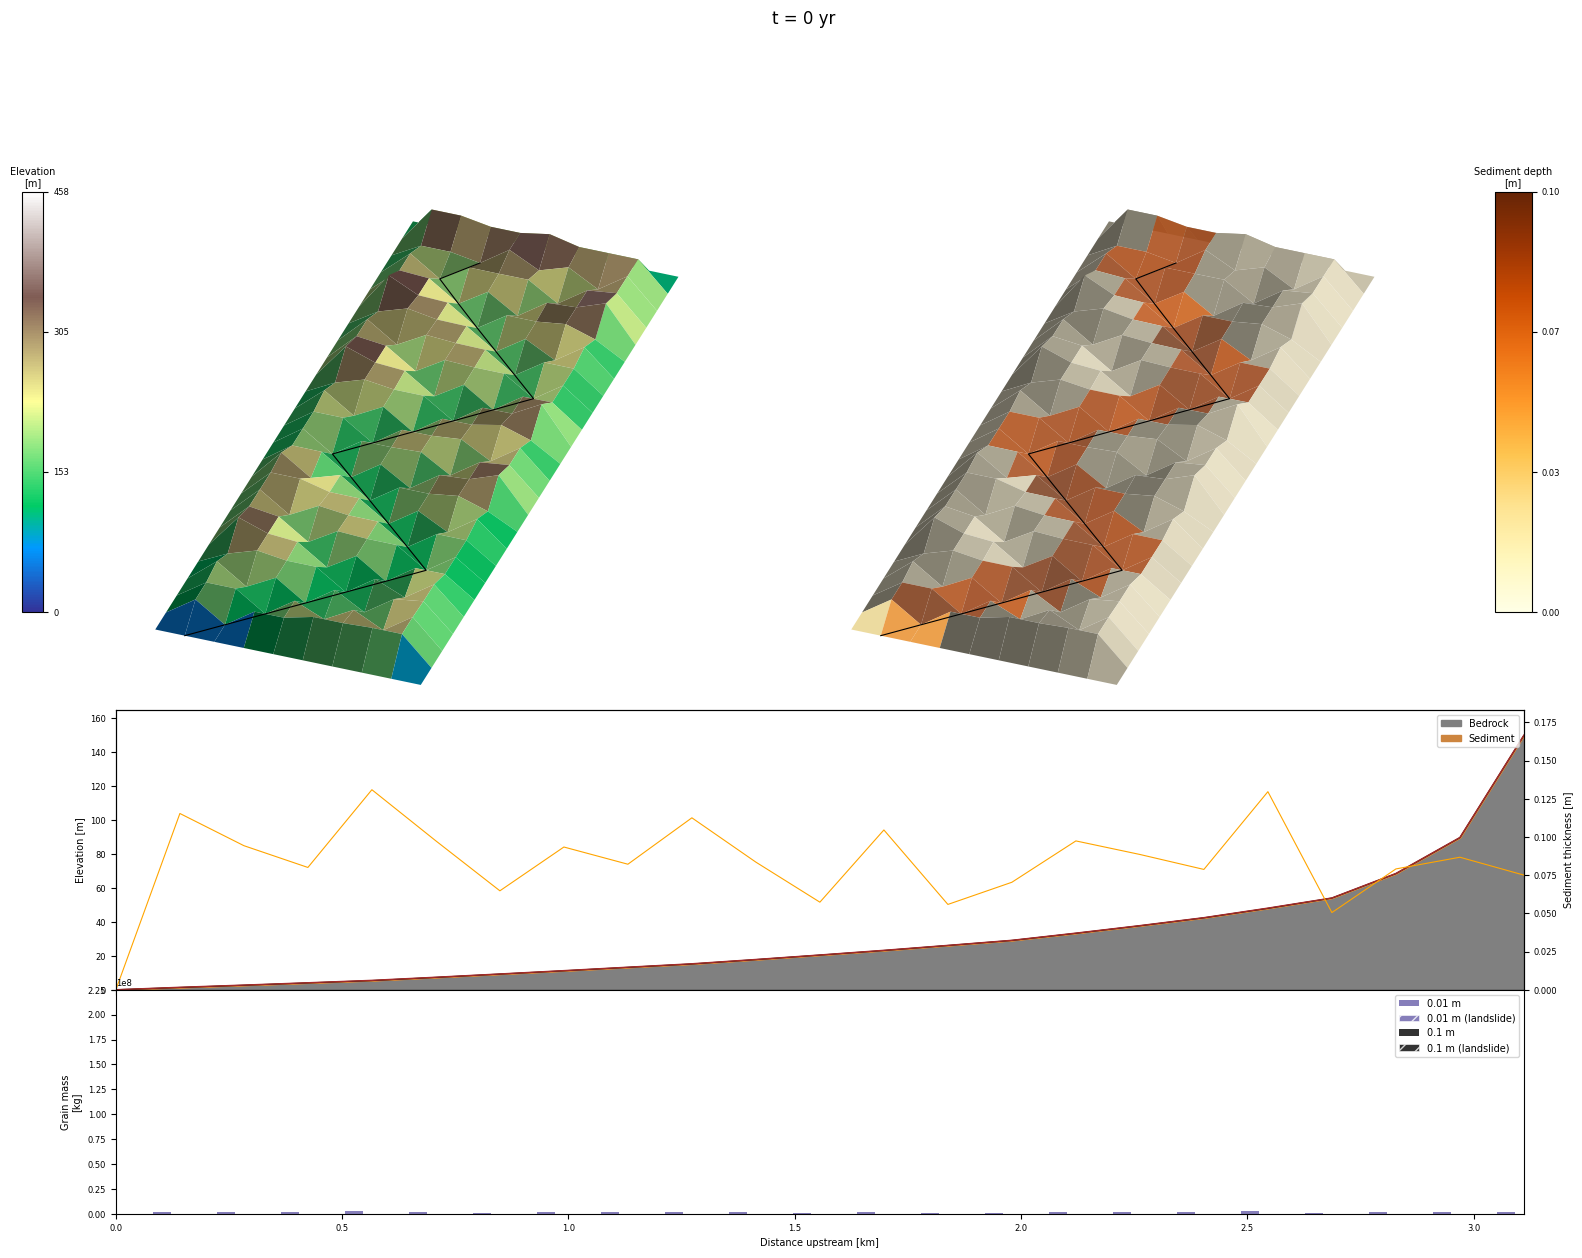

  landslide erosion  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³
  landslide deposit  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³


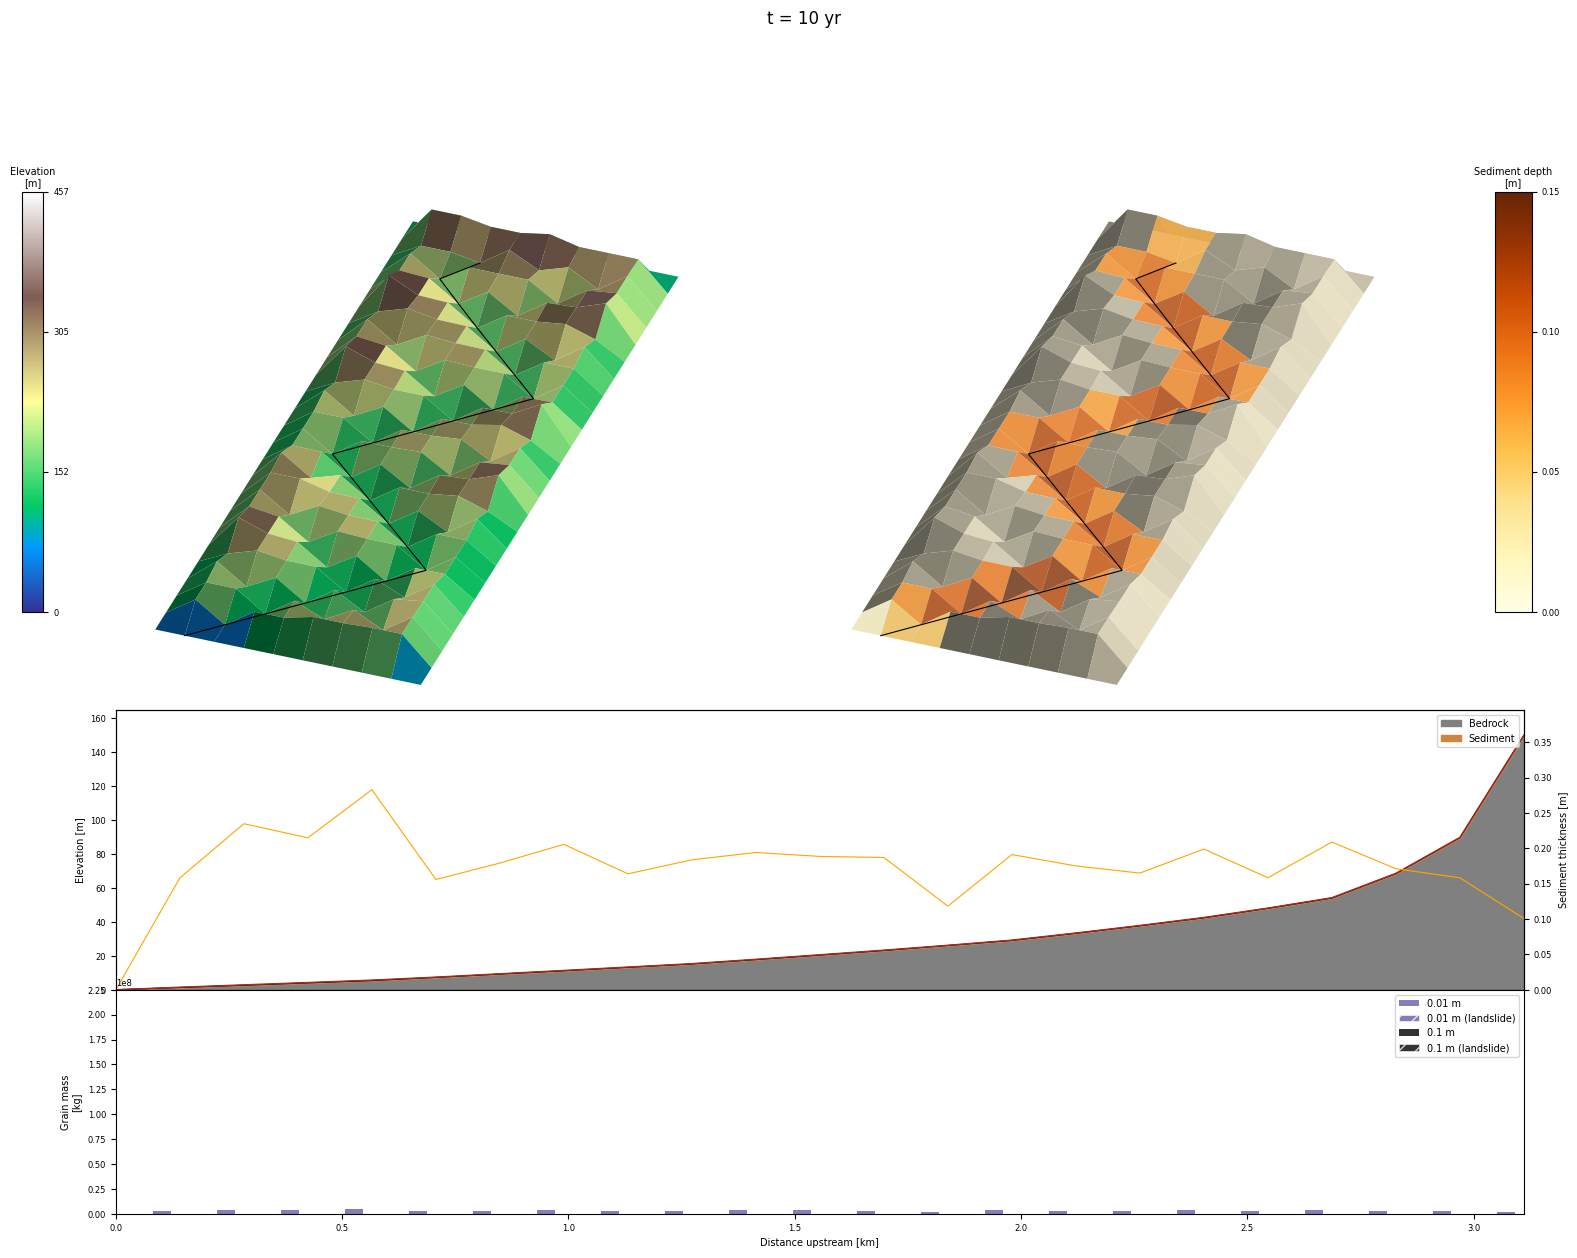

  landslide erosion  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³
  landslide deposit  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³


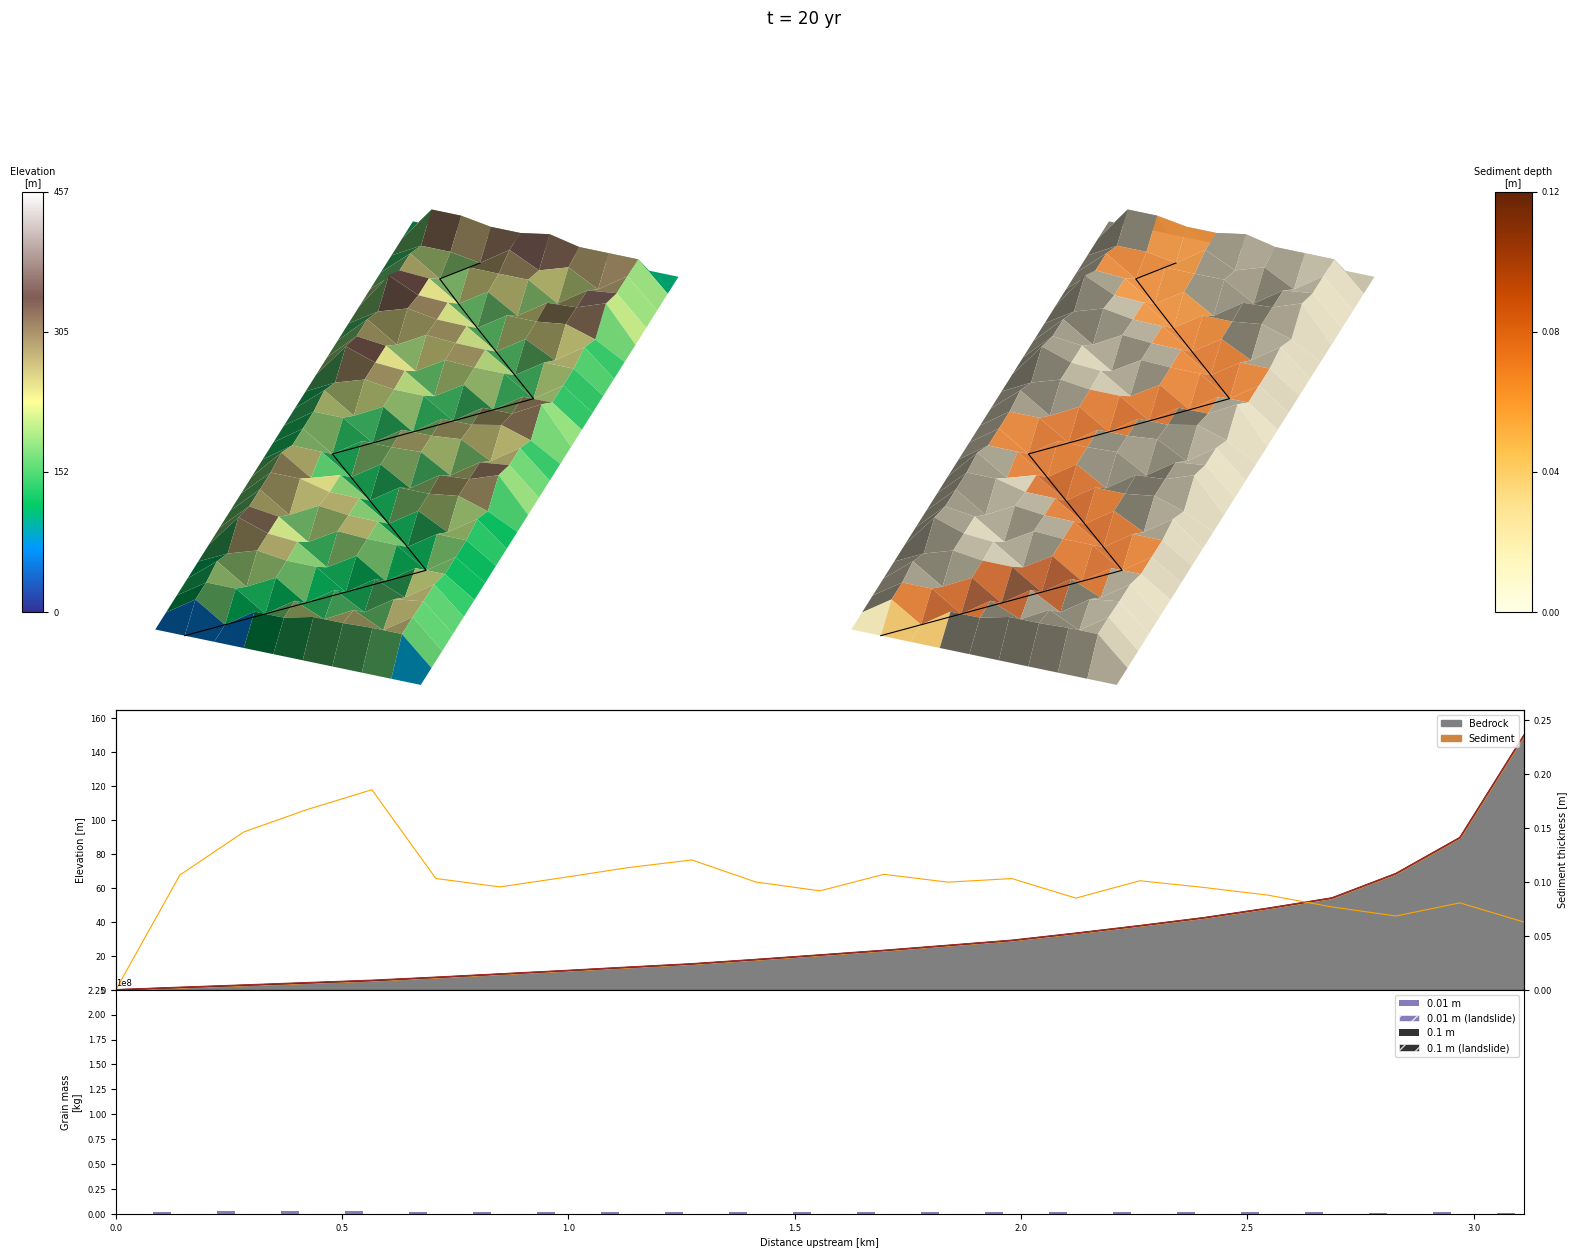

  landslide erosion  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³
  landslide deposit  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³


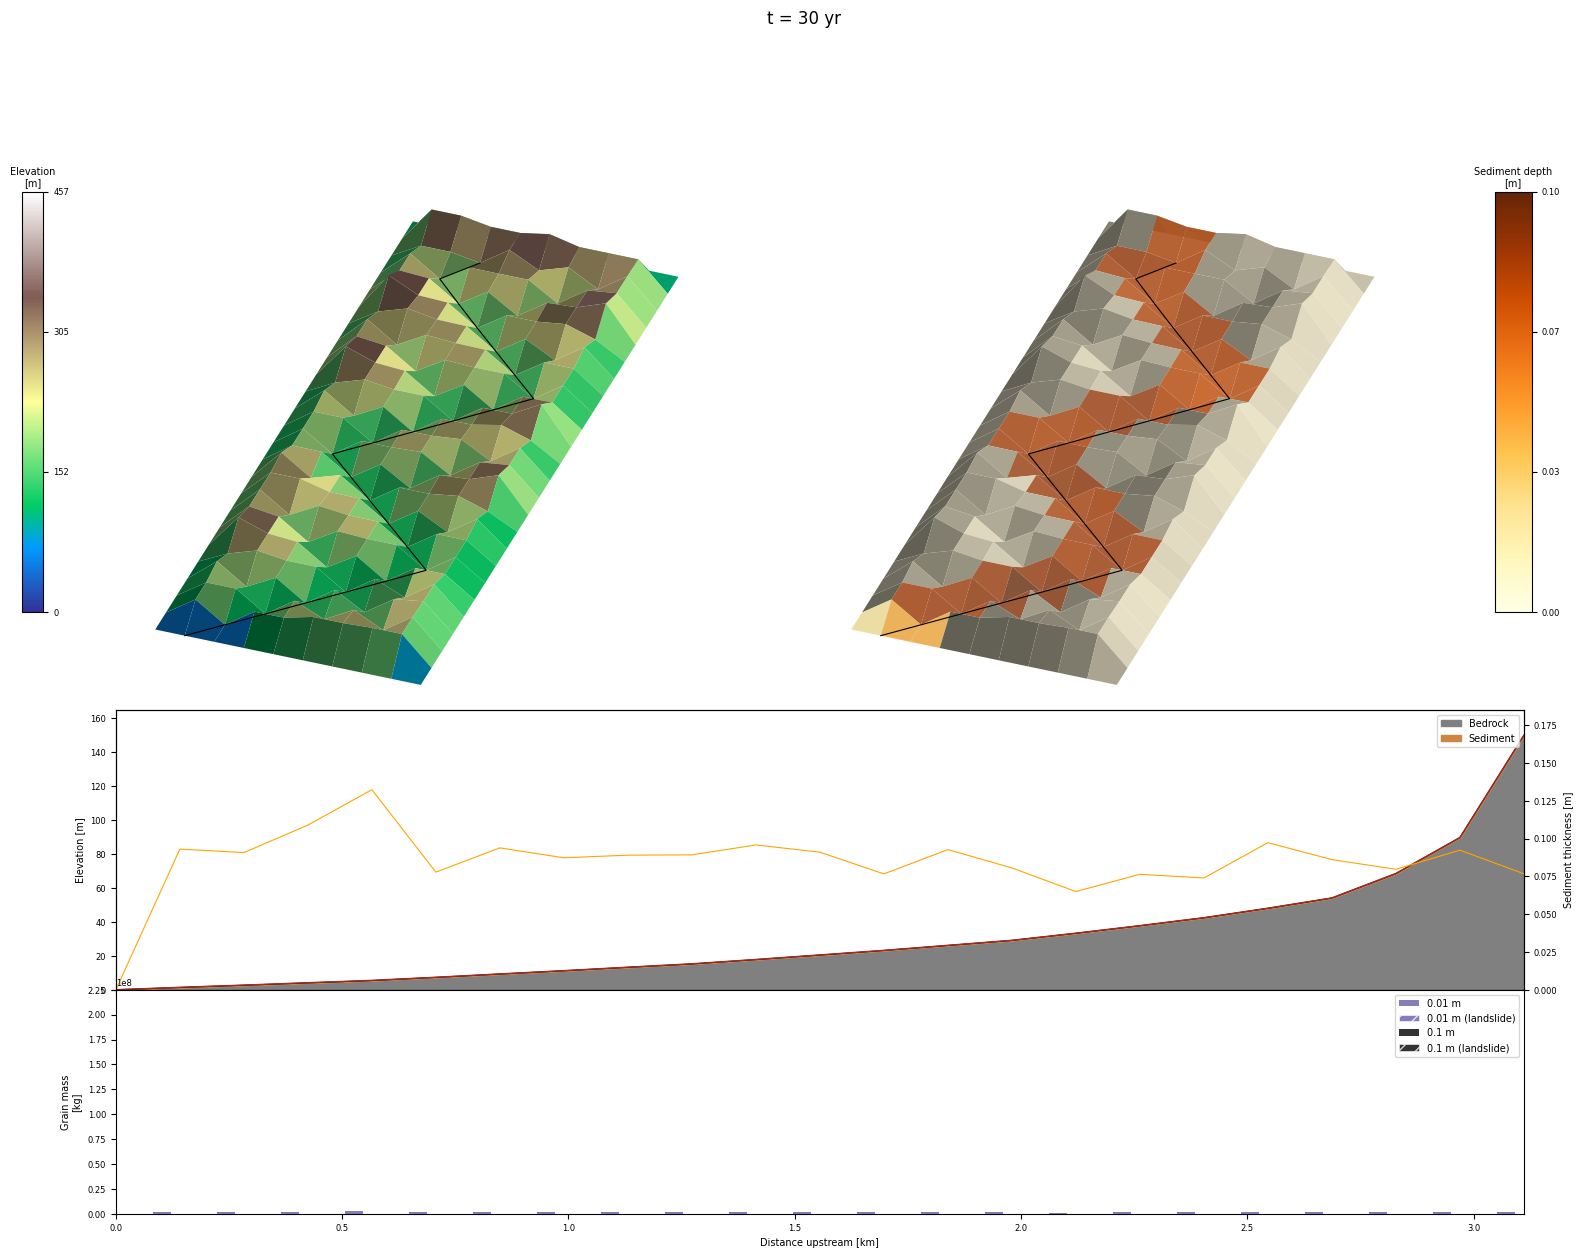

  landslide erosion  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³
  landslide deposit  — nodes active:    0, max dz: 0.000 m, total vol: 0.0 m³
t=40: landslide deposition ON CHANNEL at nodes [12, 23, 34, 45, 56, 67, 76, 85, 94, 103, 112, 123, 134, 145]


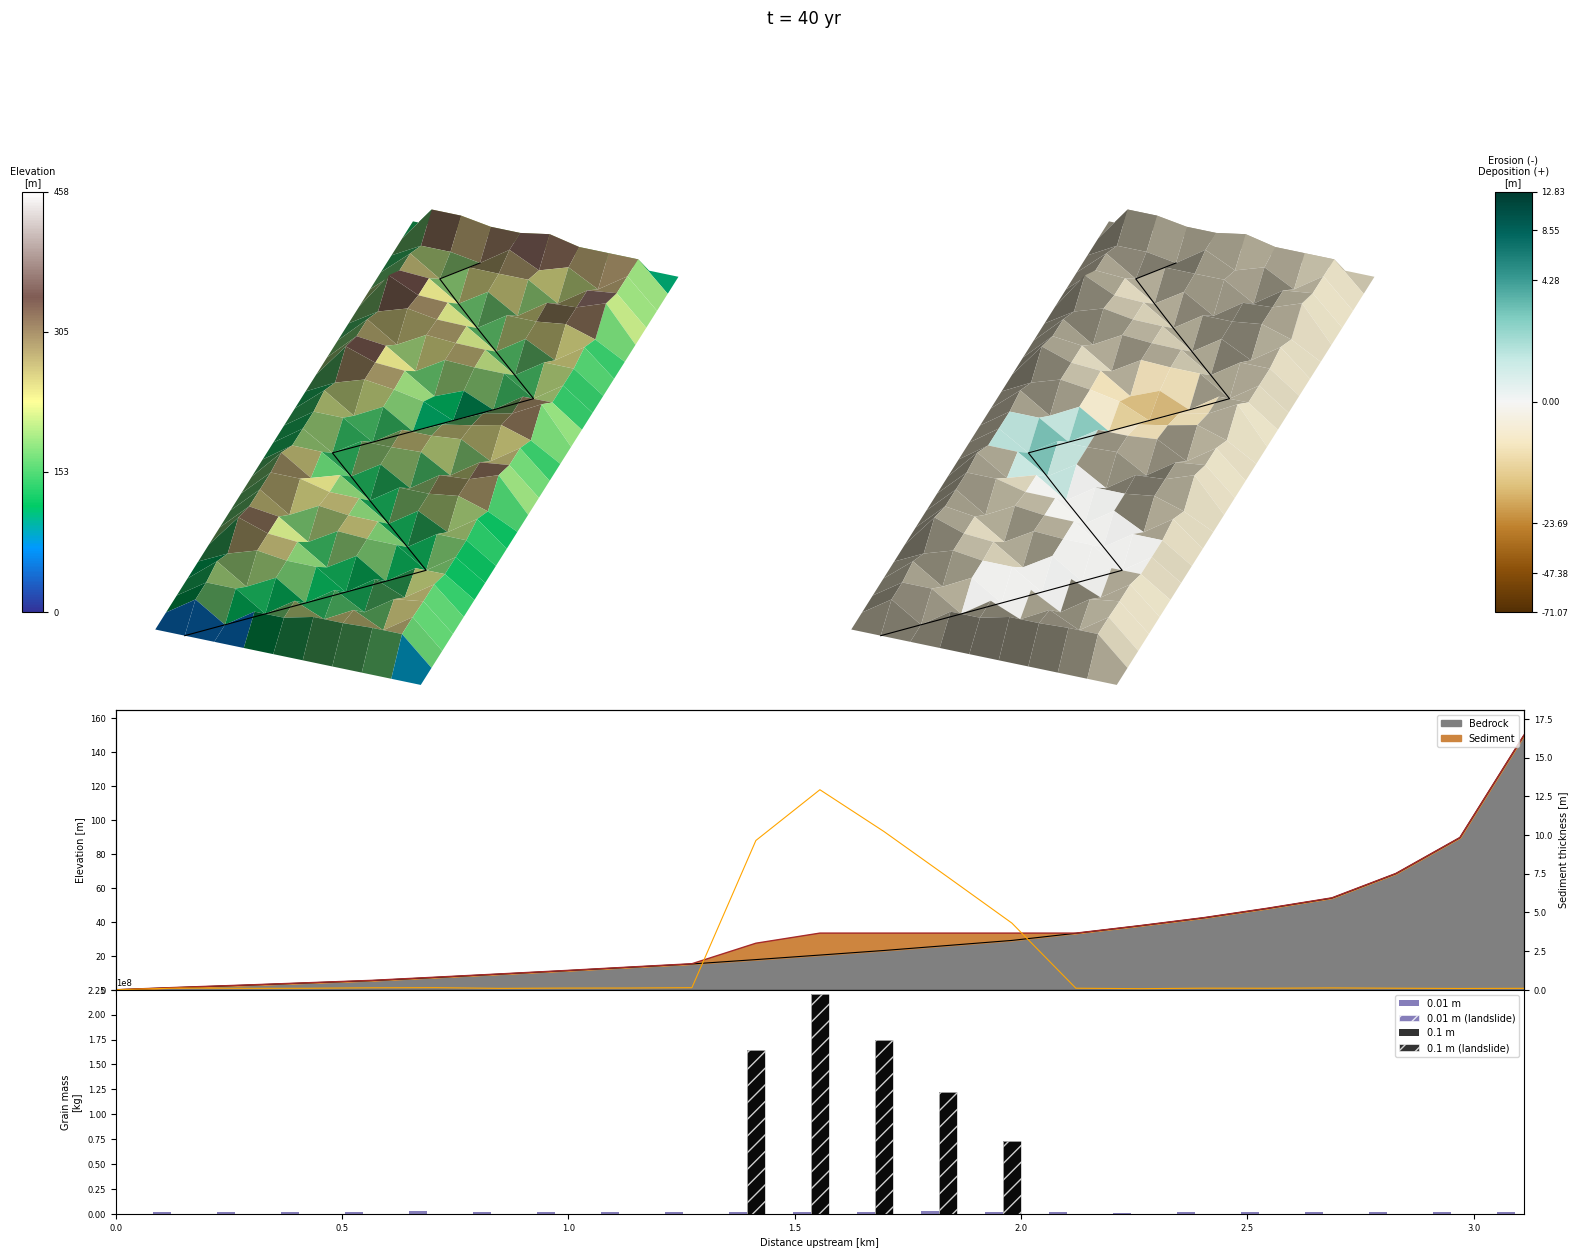

  landslide erosion  — nodes active:    5, max dz: 71.070 m, total vol: 2846975.7 m³
  landslide deposit  — nodes active:   14, max dz: 12.832 m, total vol: 438268.9 m³
Done — 0.1 min total


In [200]:
uplift_rate   = 1e-3
time_step     = 10
total_time    = 41 # int(1e5)        # short run — just to observe update_mass behaviour
plot_interval = 10 # int(2e4)
show_only_current_ls_sed = True

start = time.time()

# set up the proporations for landslide deposition, this is new
n_nodes = grid.number_of_nodes
n_classes = 2
ls_sed_proportions = [0, 1]#[0.5, 0.5]
proportions_array = np.tile(ls_sed_proportions, (n_nodes, 1))  # shape (n_nodes, n_classes)

# need to add something to track landslide material; this field will accumulate the positive change in grains__weight at each timestep,
#    recording every kg of mass that arrives at a node via landslide deposition since the model start
#    mass is not subtracted as it's moved downstream via fluvial transport.
grid.at_node['landslide_grains__weight'] = np.zeros((grid.number_of_nodes, n_classes))

# storing data
profile_history= []
grain_history = []

# setting up fixed axes and ranges
elev_min = grid.at_node['topographic__elevation'].min()
elev_max = grid.at_node['topographic__elevation'].max() + uplift_rate * total_time  # account for uplift

fixed_ranges = {
    'elev':        (elev_min, elev_max),
    'erosion':     (0, 1),       # m — set based on expected max landslide erosion
    'deposition':  (0, 20),       # m
    'relief':      (0, elev_max),  # channel profile y axis
    'soil':        (0, 20),       # m — sediment thickness
    'grain_mass':  (0, 7e7),       # kg — grain mass y axis
}

mpl.rcParams.update({
    'font.size':        8,   # default for everything
    'axes.labelsize':   7,   # x and y axis labels
    'xtick.labelsize':  6,   # tick numbers
    'ytick.labelsize':  6,
    'legend.fontsize':  6,
    'axes.titlesize':   7,
})

# bit to capture every landslide event, find where it deposits on the channel and build up a running list to use
all_ls_channel_nodes = []       # accumulates every (time, node, depth) that lands on the channel
all_ls_dep_nodes_full = []      # accumulates every deposition node, channel or not

profile_history_1 = []
grain_history_yuval_1 = []

for i in range(0, total_time, time_step):

    fr.run_one_step()
    eroder.run_one_step(time_step)
    grid.at_node['landslide_grains__weight'] = np.zeros((grid.number_of_nodes, n_classes))
    ls.run_one_step(time_step)
    dep_nodes = np.where(grid.at_node['landslide__deposition'] > 0)[0]

    if len(dep_nodes) > 0:
        # need channel nodes at this same timestep
        profiler_now = ChannelProfiler(
            grid, number_of_watersheds=1,
            minimum_channel_threshold=20000, main_channel_only=True,
        )
        profiler_now.run_one_step()
        ch_nodes_now = (np.concatenate(profiler_now.nodes) if isinstance(profiler_now.nodes, list)
                        else profiler_now.nodes.ravel())

        ls_dep_on_channel = np.intersect1d(dep_nodes, ch_nodes_now)

        # log everything, channel or not
        for n in dep_nodes:
            all_ls_dep_nodes_full.append({
                'time': i,
                'node': n,
                'depth': grid.at_node['landslide__deposition'][n],
                'on_channel': n in ls_dep_on_channel,
            })

        if len(ls_dep_on_channel) > 0:
            print(f"t={i}: landslide deposition ON CHANNEL at nodes {ls_dep_on_channel.tolist()}")
            for n in ls_dep_on_channel:
                all_ls_channel_nodes.append(n)
                
    grains_before = grid.at_node['grains__weight'].copy()
    
    sg.update_mass_based_on_outsource_dz(proportions=proportions_array)

    landslide_contribution = grid.at_node['grains__weight'] - grains_before
    grid.at_node['landslide_grains__weight'] += np.maximum(landslide_contribution, 0)

    grid.at_node['bedrock__elevation'][grid.core_nodes] += uplift_rate * time_step
    grid.at_node['topographic__elevation'][:] = (
        grid.at_node['bedrock__elevation'] + grid.at_node['soil__depth']
    )

    if i % plot_interval == 0:
        profiler = ChannelProfiler(
            grid, number_of_watersheds=1,
            minimum_channel_threshold=20000, main_channel_only=True,
        )
        profiler.run_one_step()

        if isinstance(profiler.nodes, list):
            ch_nodes = np.concatenate(profiler.nodes)
        else:
            ch_nodes = profiler.nodes.ravel()
        dists_km = (profiler.distance_along_profile[0].max() - profiler.distance_along_profile[0]) * 1e-3
        grain_history_yuval_1.append({
            'time' : i,
            'grains' : grid.at_node['grains__weight'][ch_nodes].copy(),
            'grains_ls' : grid.at_node['landslide_grains__weight'][ch_nodes].copy(),
            'dists_km' : dists_km,
                })
        profile_history_1.append({
            'time':    i,
            'dist_km': profiler.distance_along_profile[0] * 1e-3,  # 0 at outlet, max upstream
            'topo':    grid.at_node['topographic__elevation'][ch_nodes].copy(),
            'soil':    grid.at_node['soil__depth'][ch_nodes].copy(),
        })
        
        #plotting
        fig, axes = plot_3d_landslide_extended(
            grid,
            figsize=(16, 14),
            profiler=profiler,                          
            grains__weight=grid.at_node['grains__weight'],
            grain_sizes_m=[0.01, 0.1],
            landslide_grains__weight=grid.at_node['landslide_grains__weight'],
            elapsed_time=i,
            z_exag=1.0,
            elev=35, azim=290,
            fixed_ranges=None,
            n_ticks=4,
            single_ls_colorbar=True,
            ls_diverging_cmap='BrBG',
            hillshade_azimuth=290,
            hillshade_altitude=30,
            topo_base_color='#F5EDD1',
            plot_cumm_landslide=True,
            plot_channel_profs_on_3d=True,
            save_fig=False,
        )
        plt.show()
        
        ls_e = grid.at_node['landslide__erosion']
        ls_d = grid.at_node['landslide__deposition']
        print(f"  landslide erosion  — nodes active: {(ls_e>0).sum():4d}, "
              f"max dz: {ls_e.max():.3f} m, total vol: {ls_e.sum()*100**2:.1f} m³")
        print(f"  landslide deposit  — nodes active: {(ls_d>0).sum():4d}, "
              f"max dz: {ls_d.max():.3f} m, total vol: {ls_d.sum()*100**2:.1f} m³")

print(f"Done — {(time.time()-start)/60:.1f} min total")

#### A landslide happens at `t=40`. Now we can turn landsliding off to see the consequence of this coarse landslide deposit after 10 kyr.

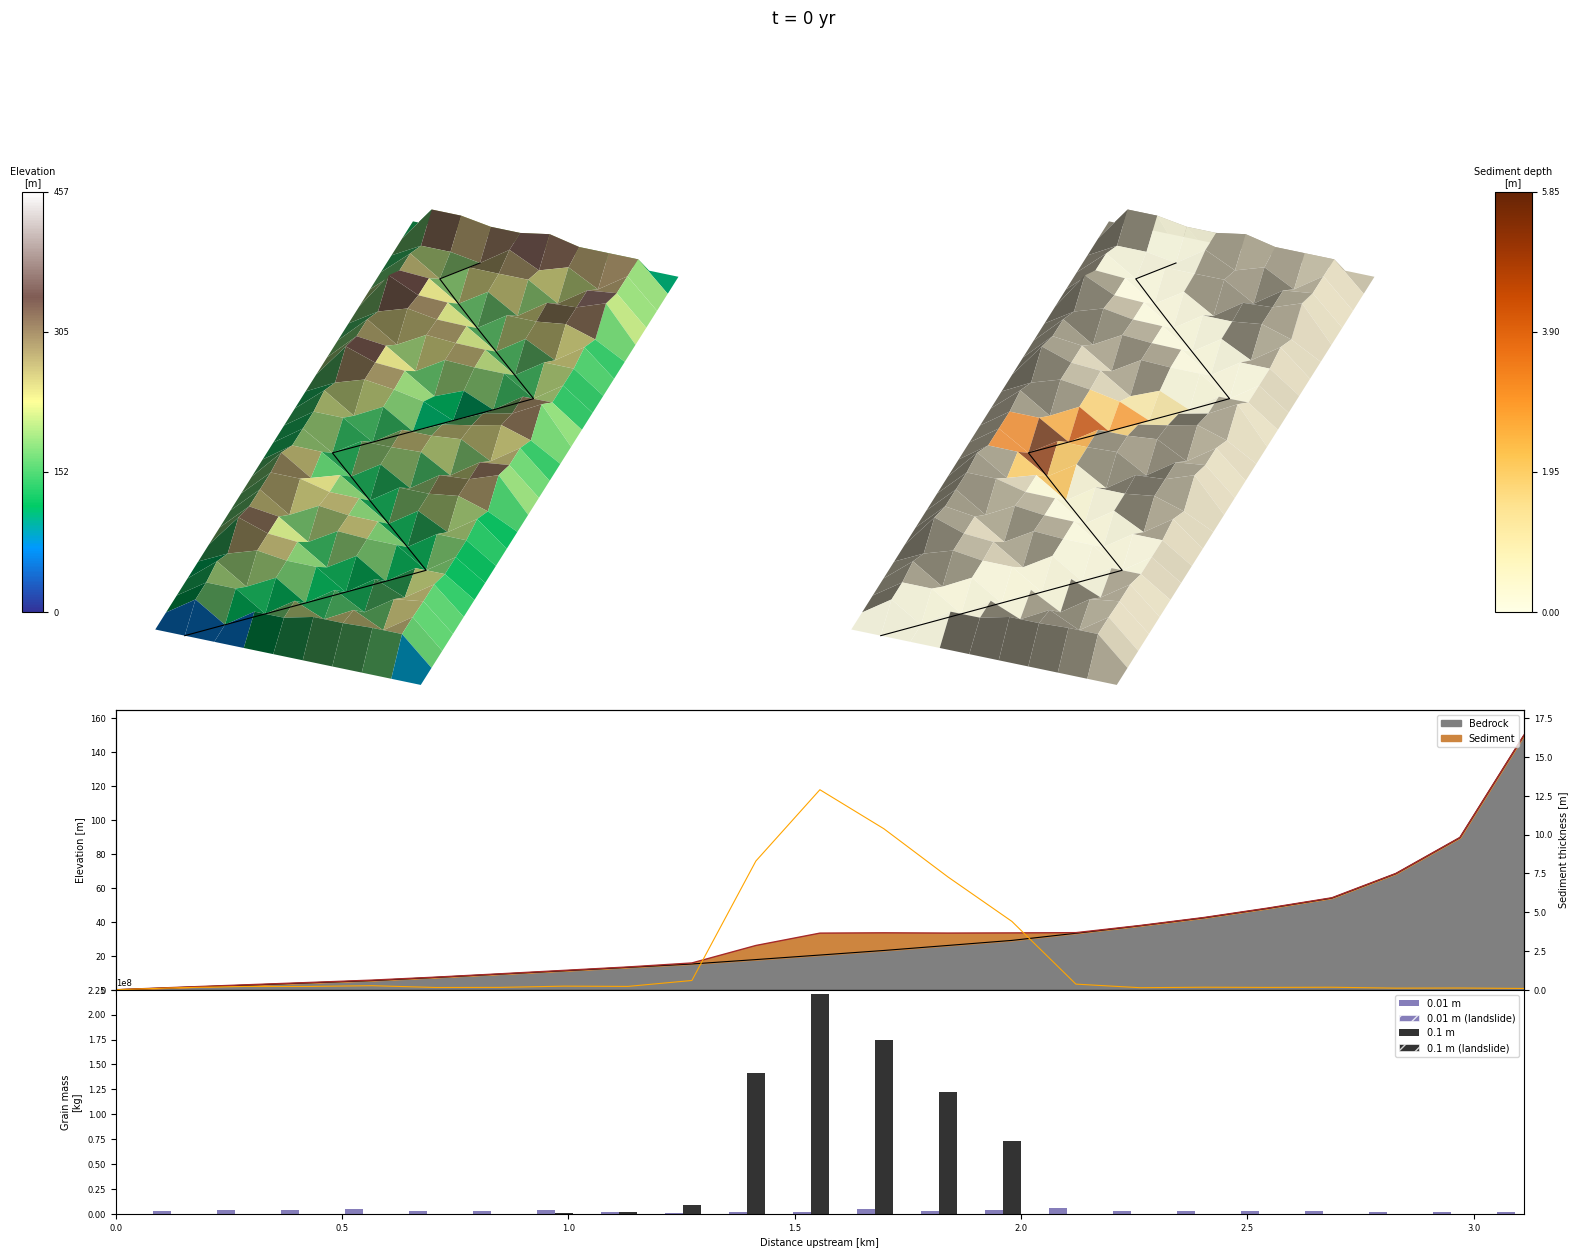

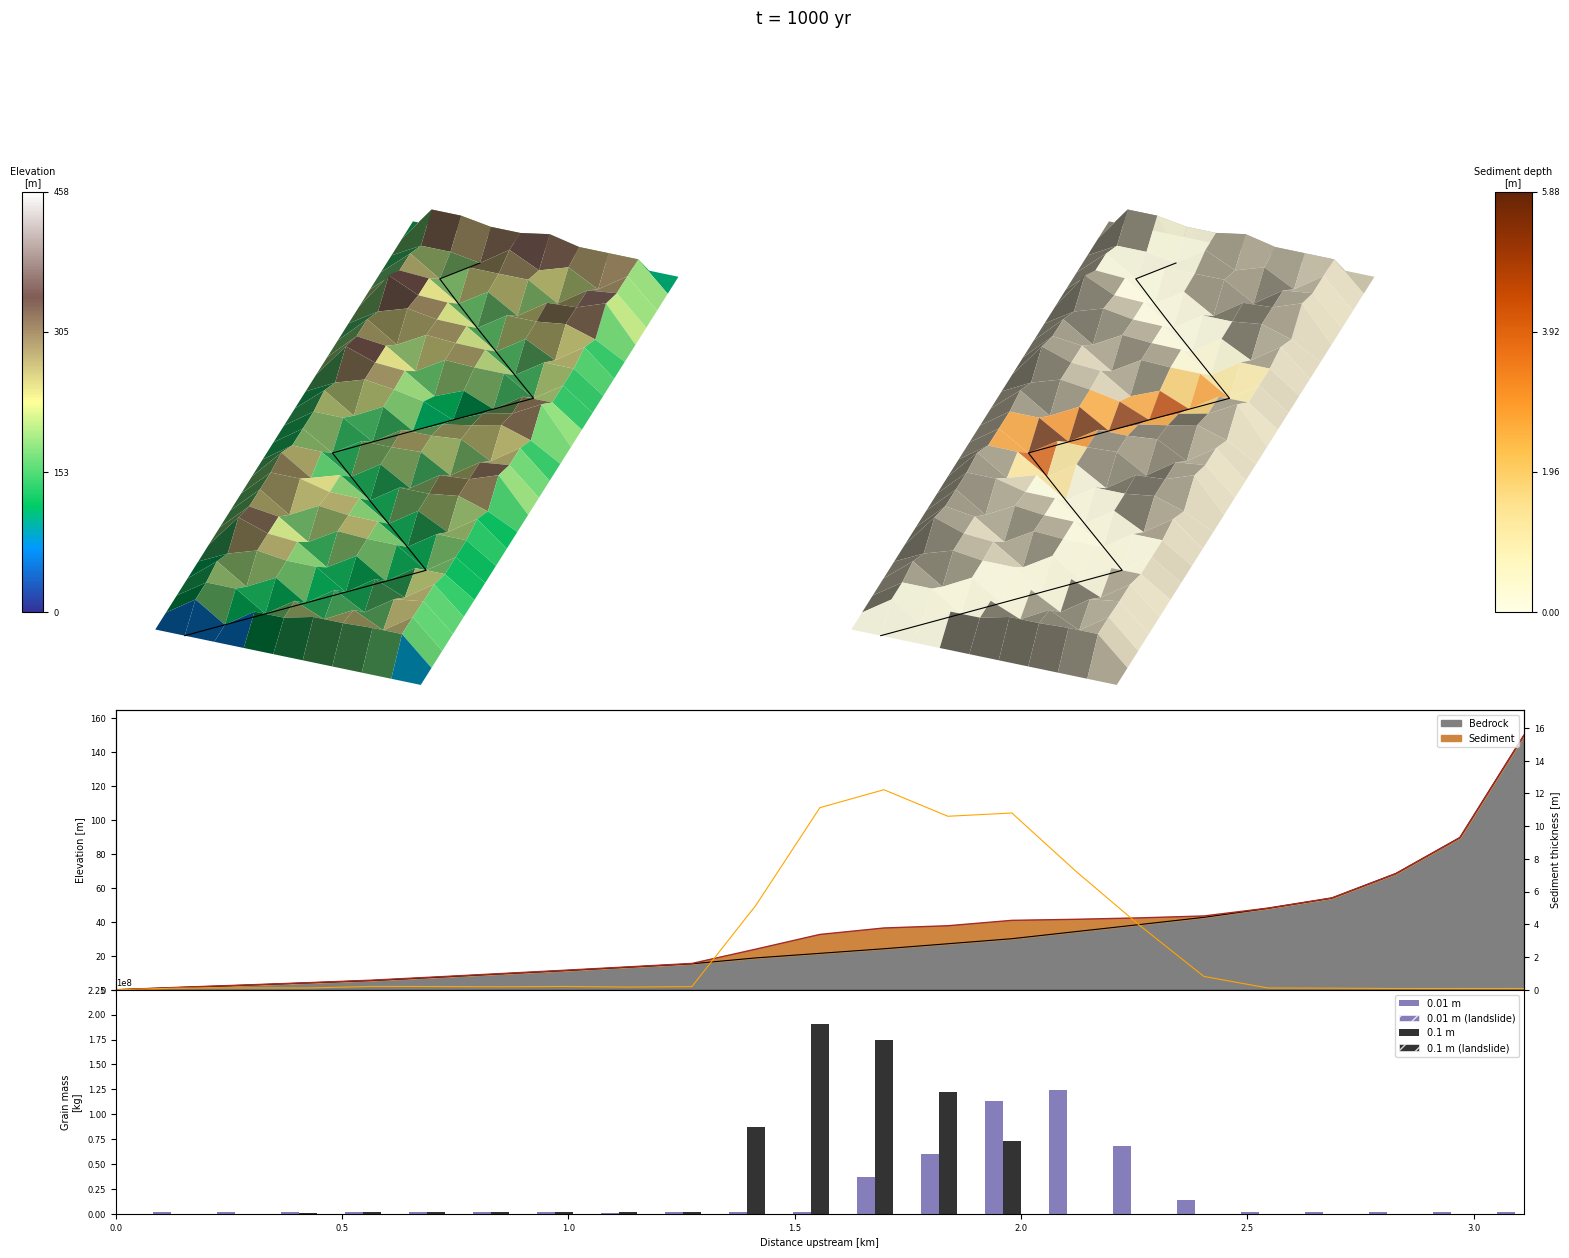

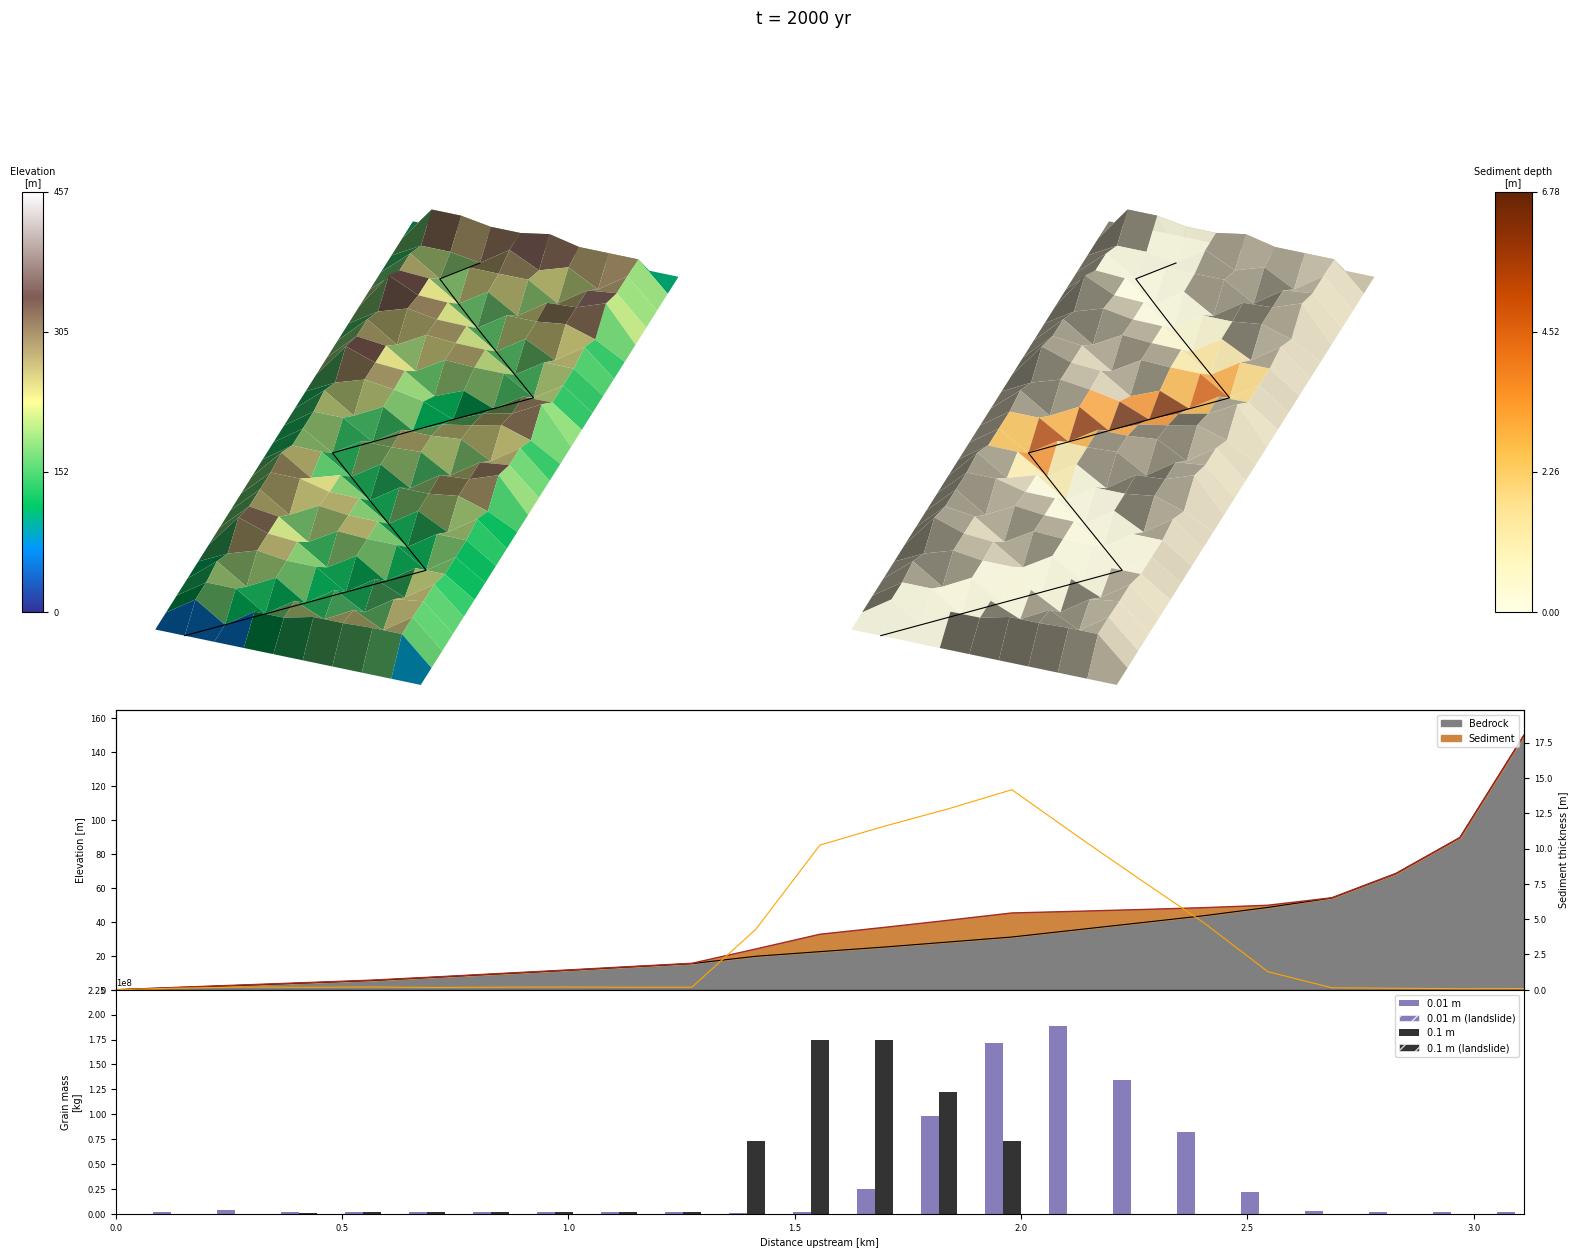

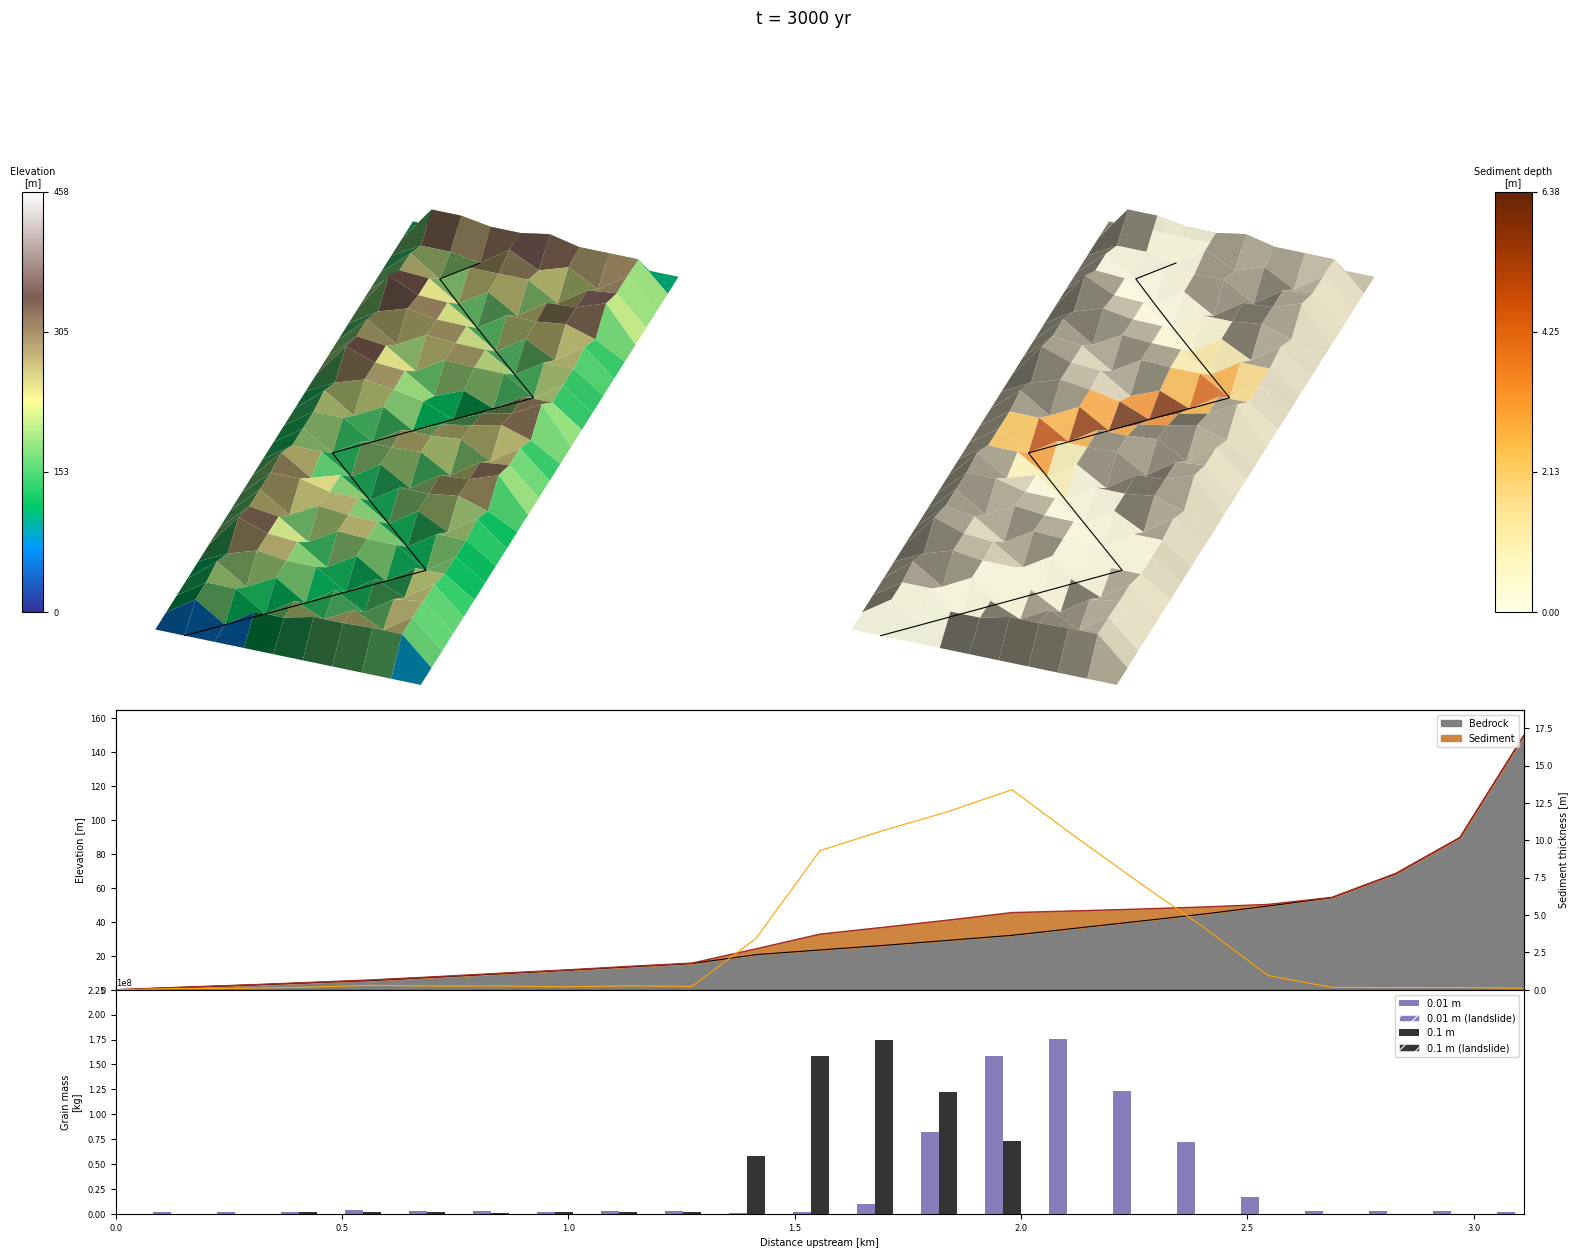

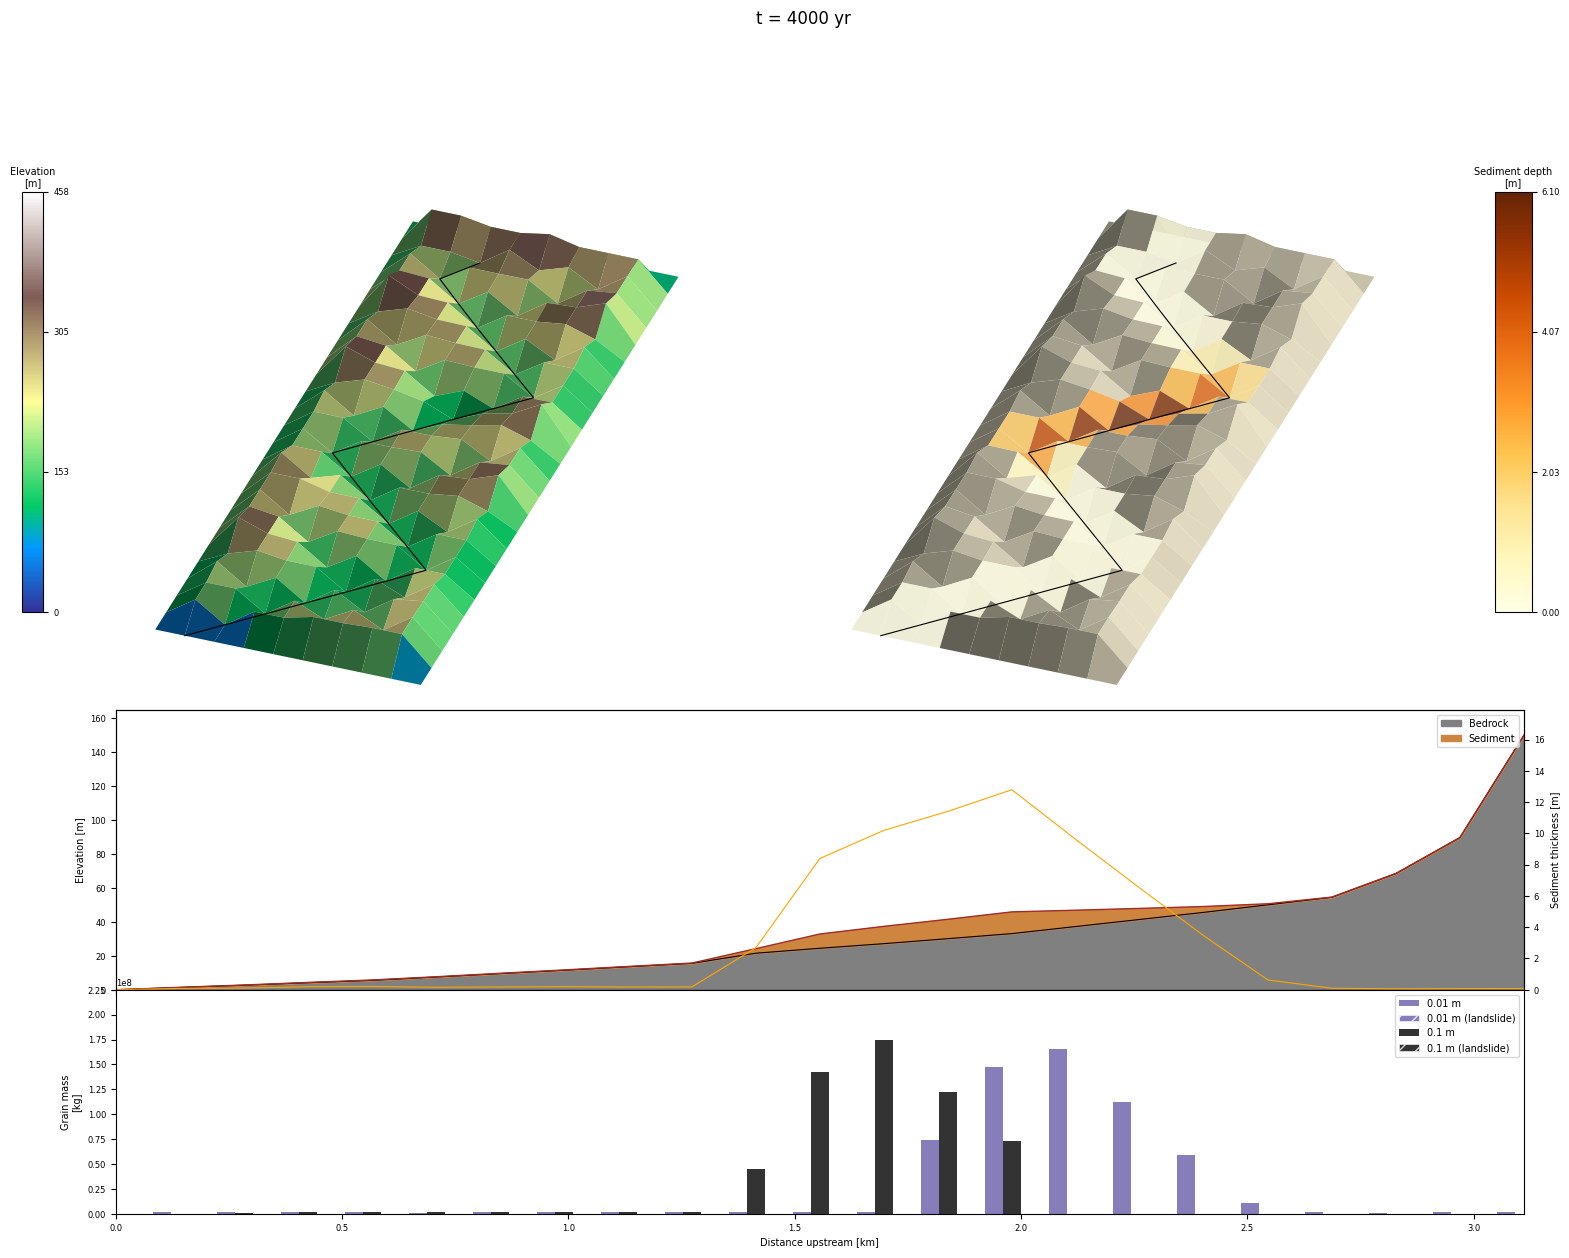

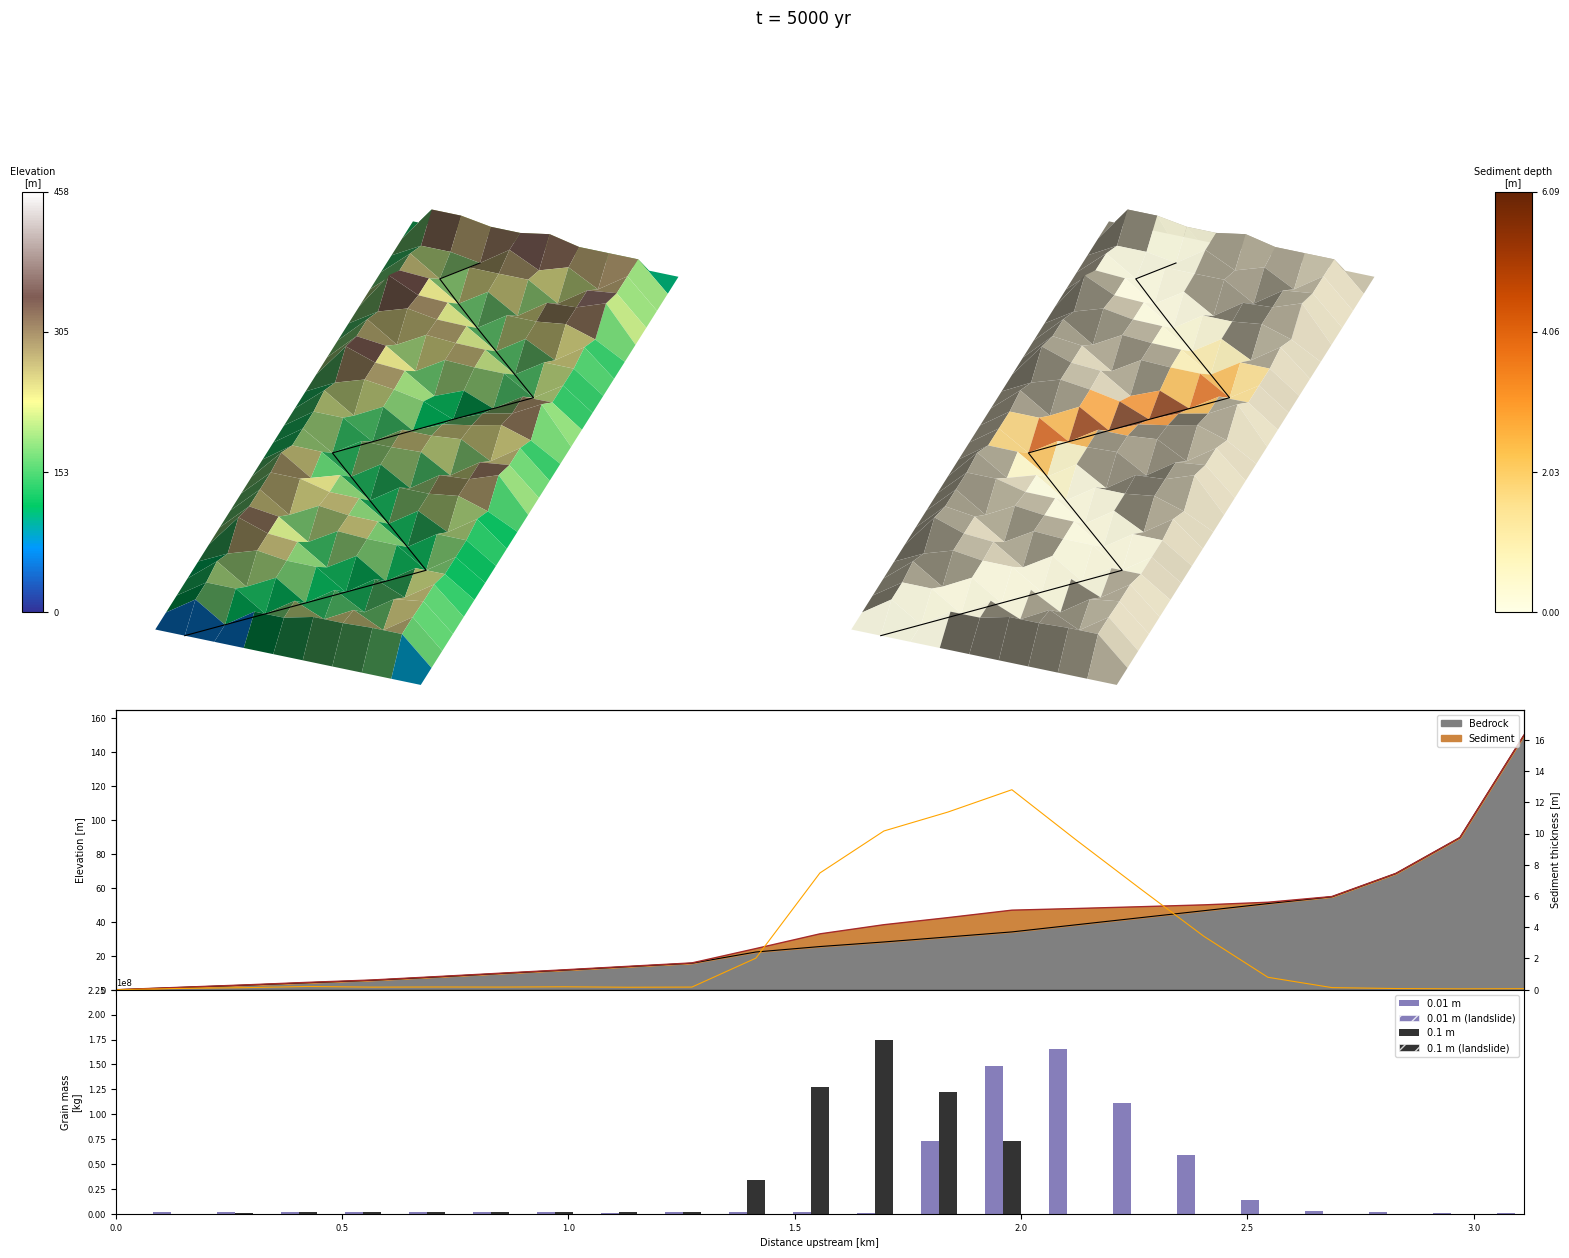

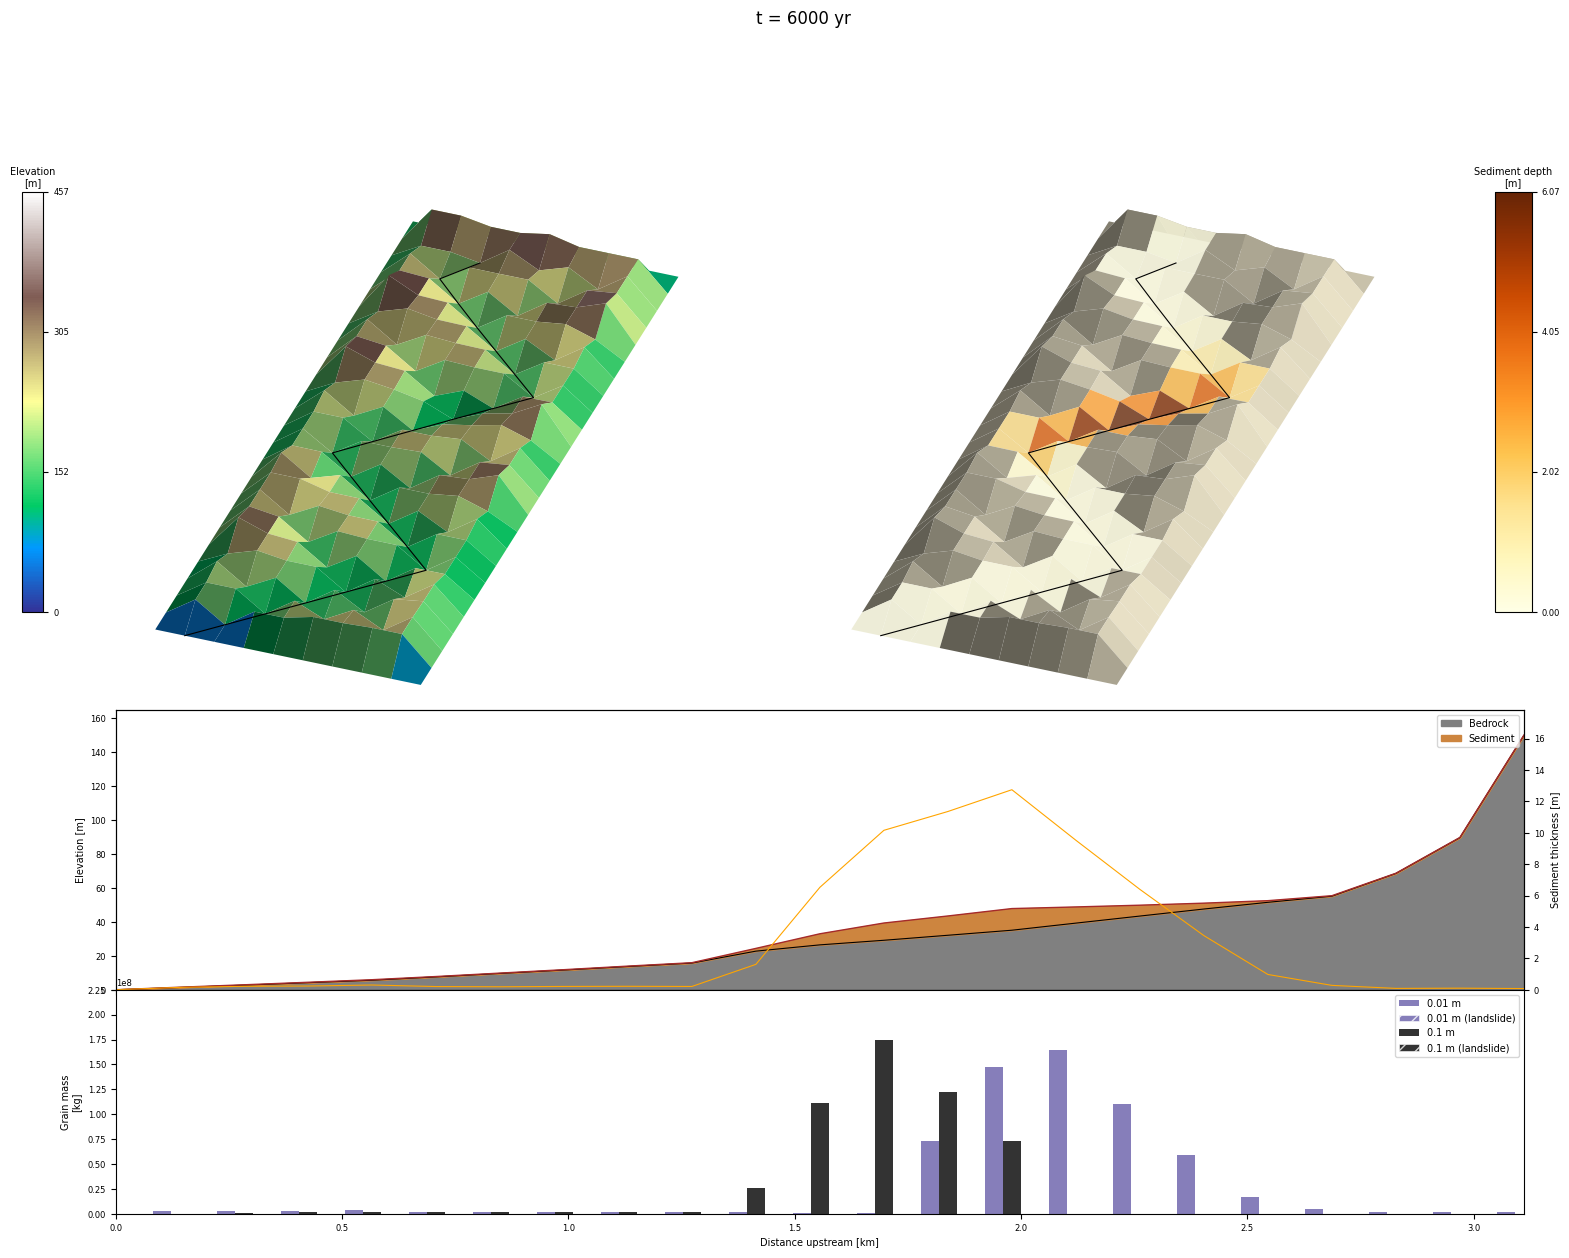

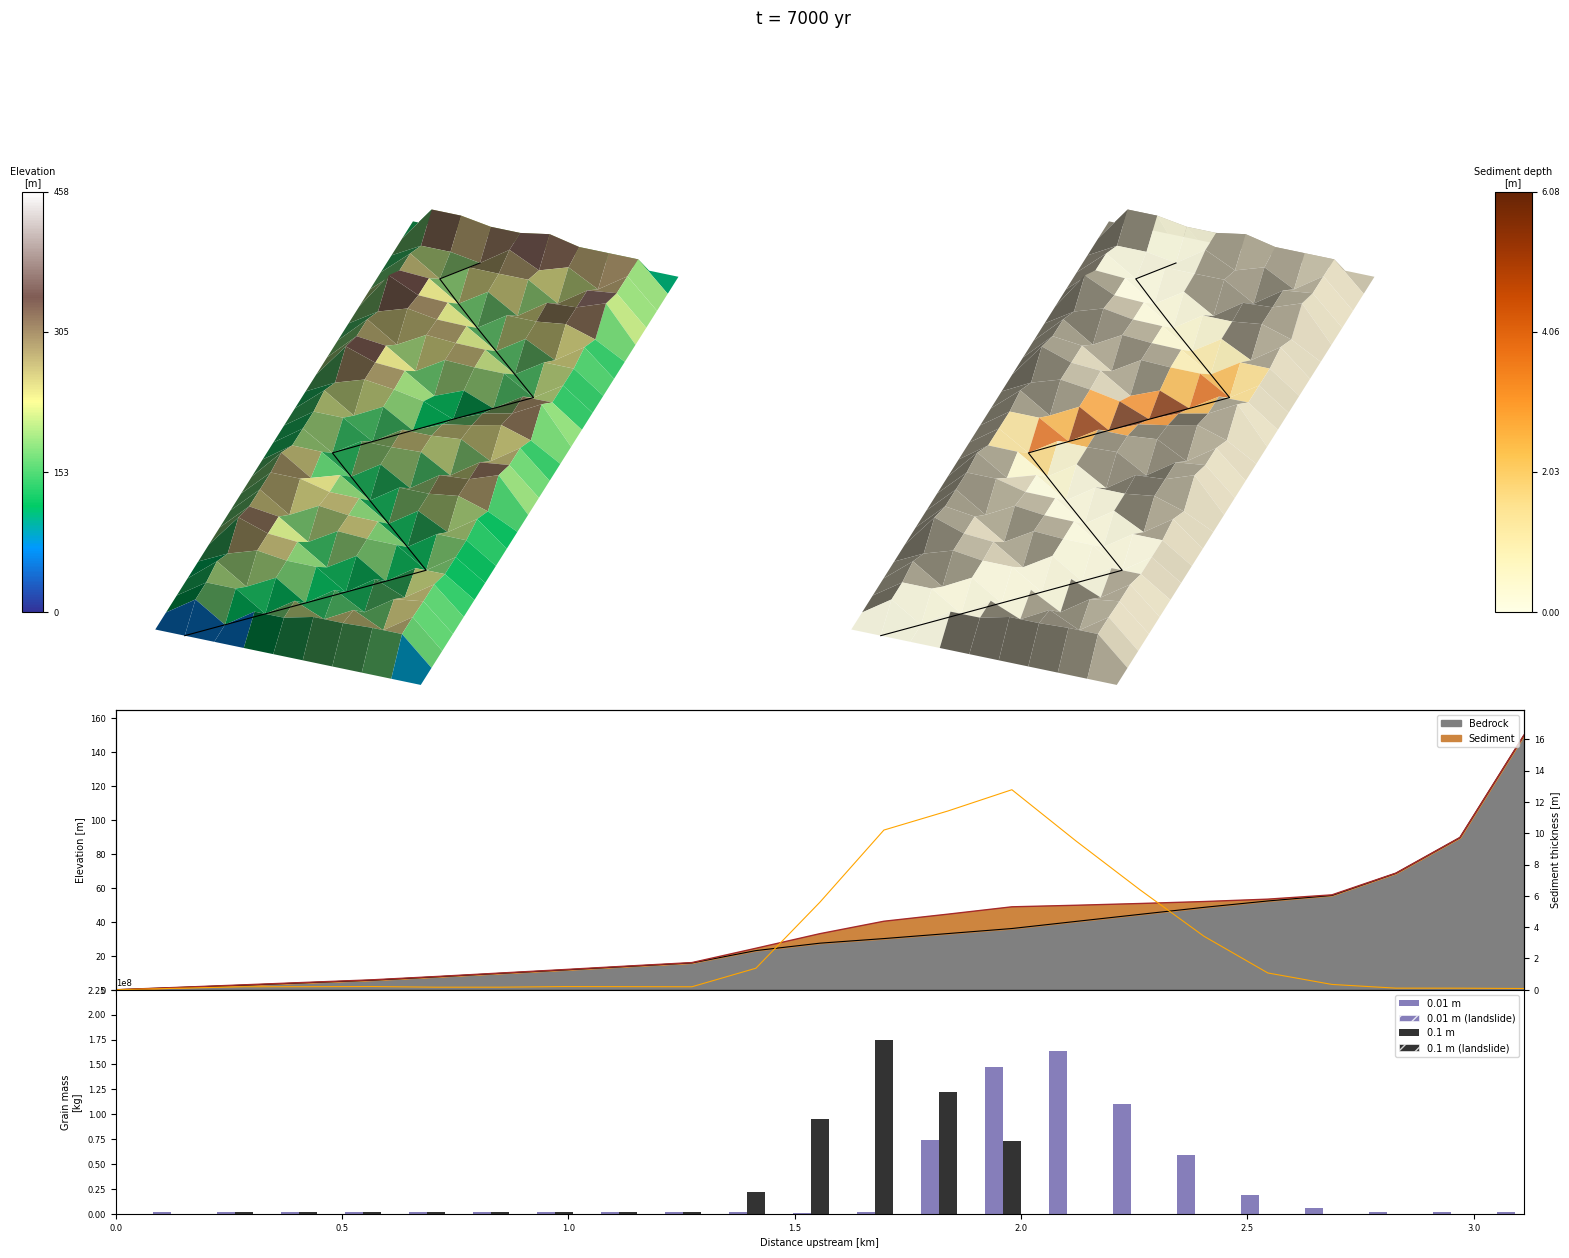

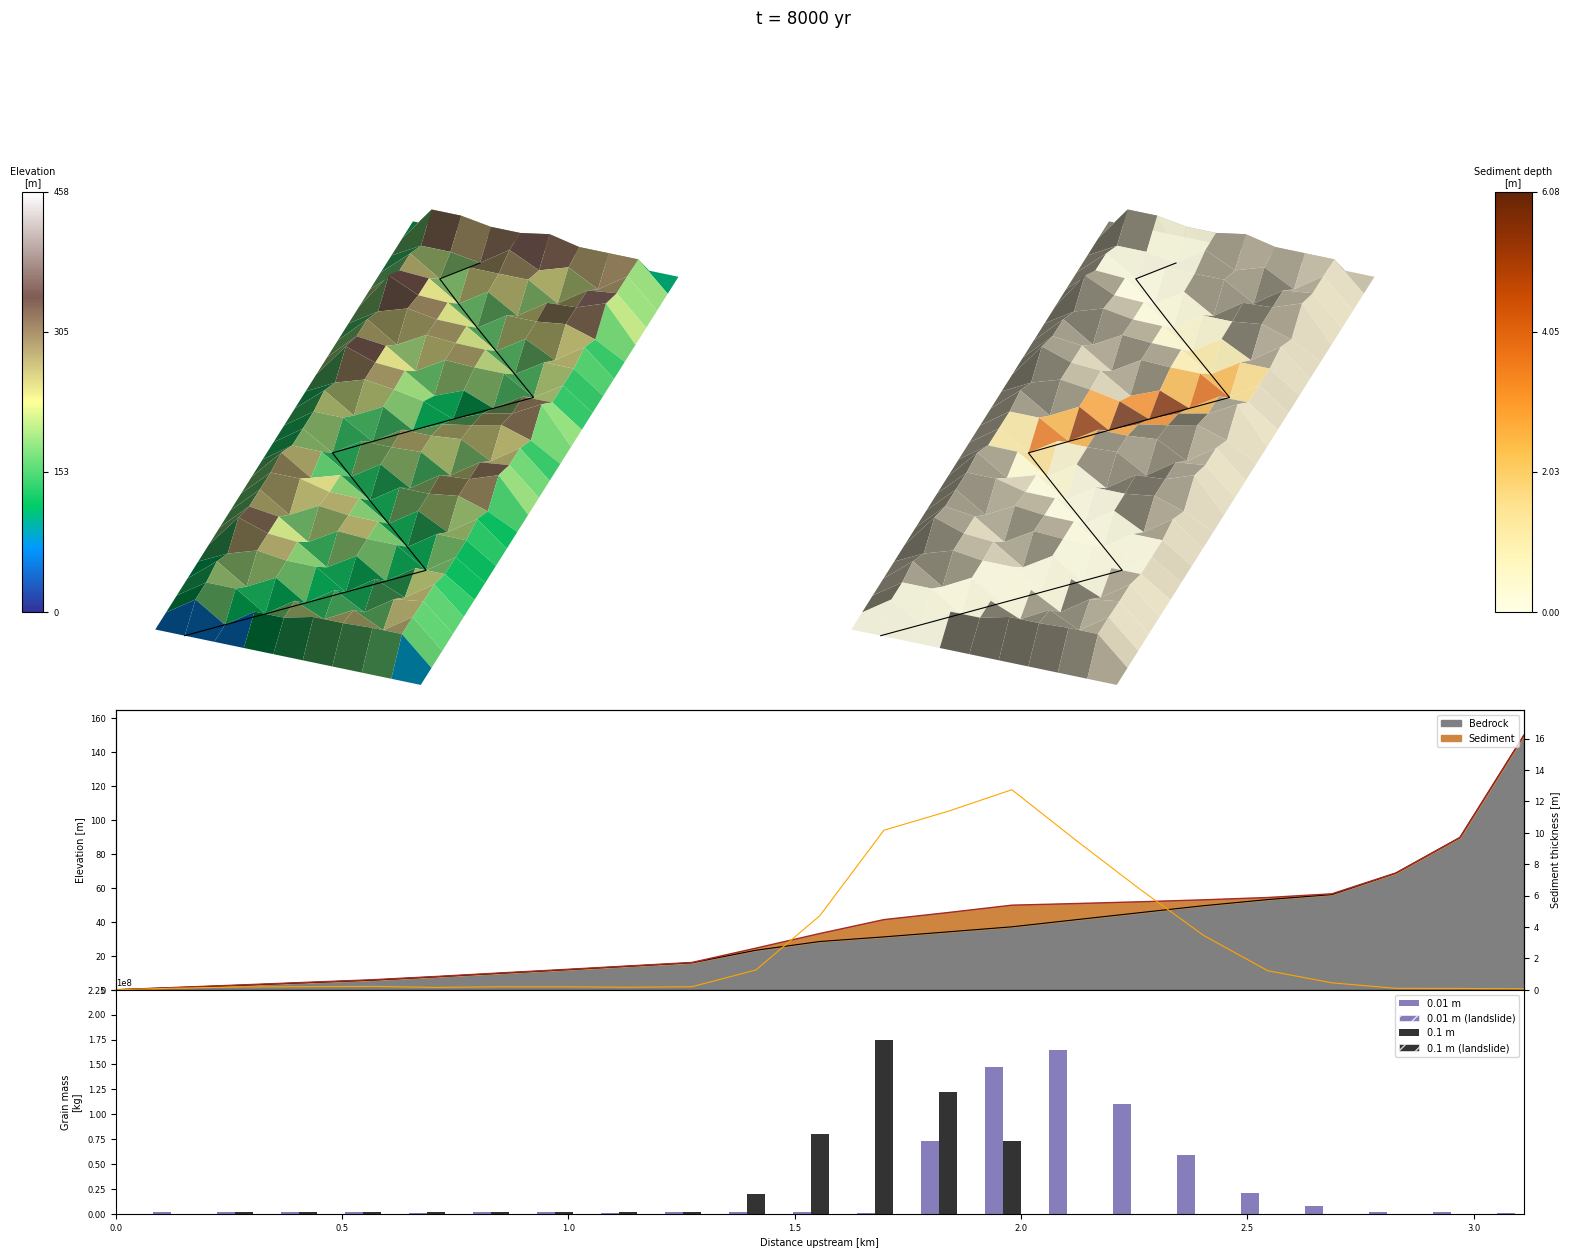

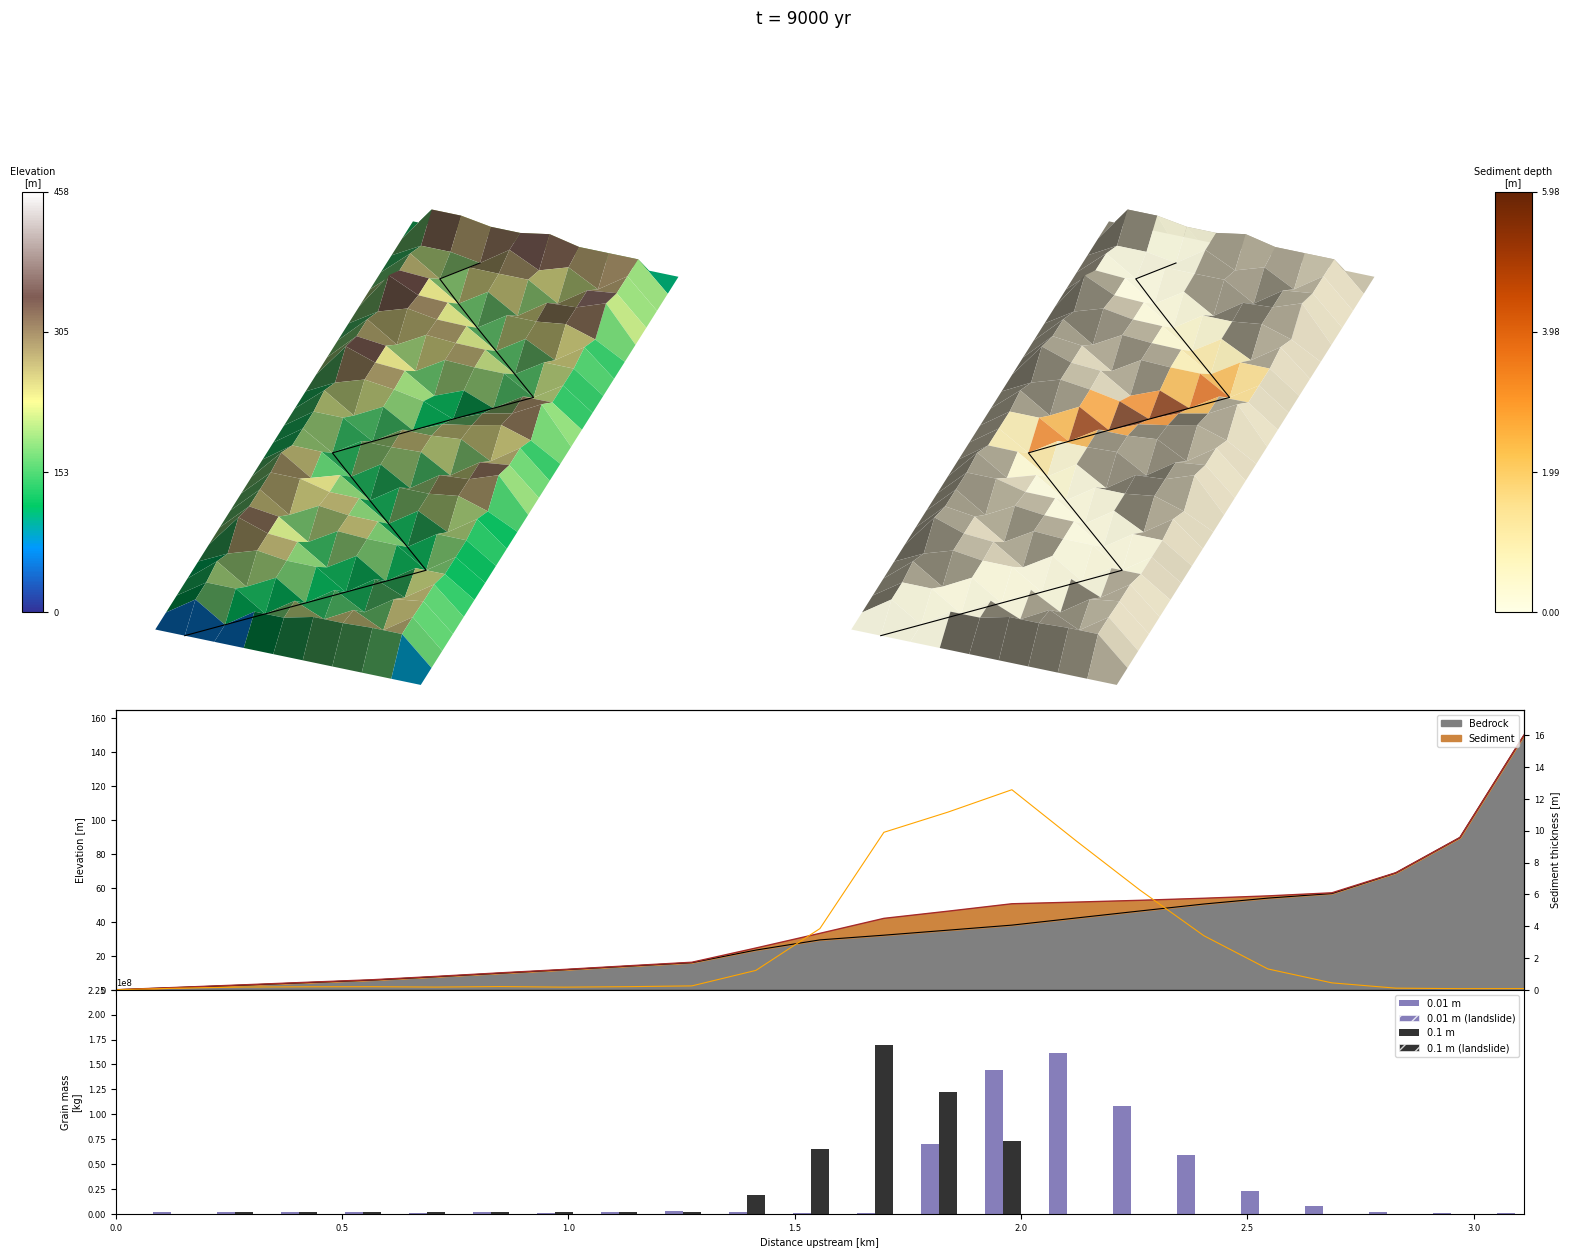

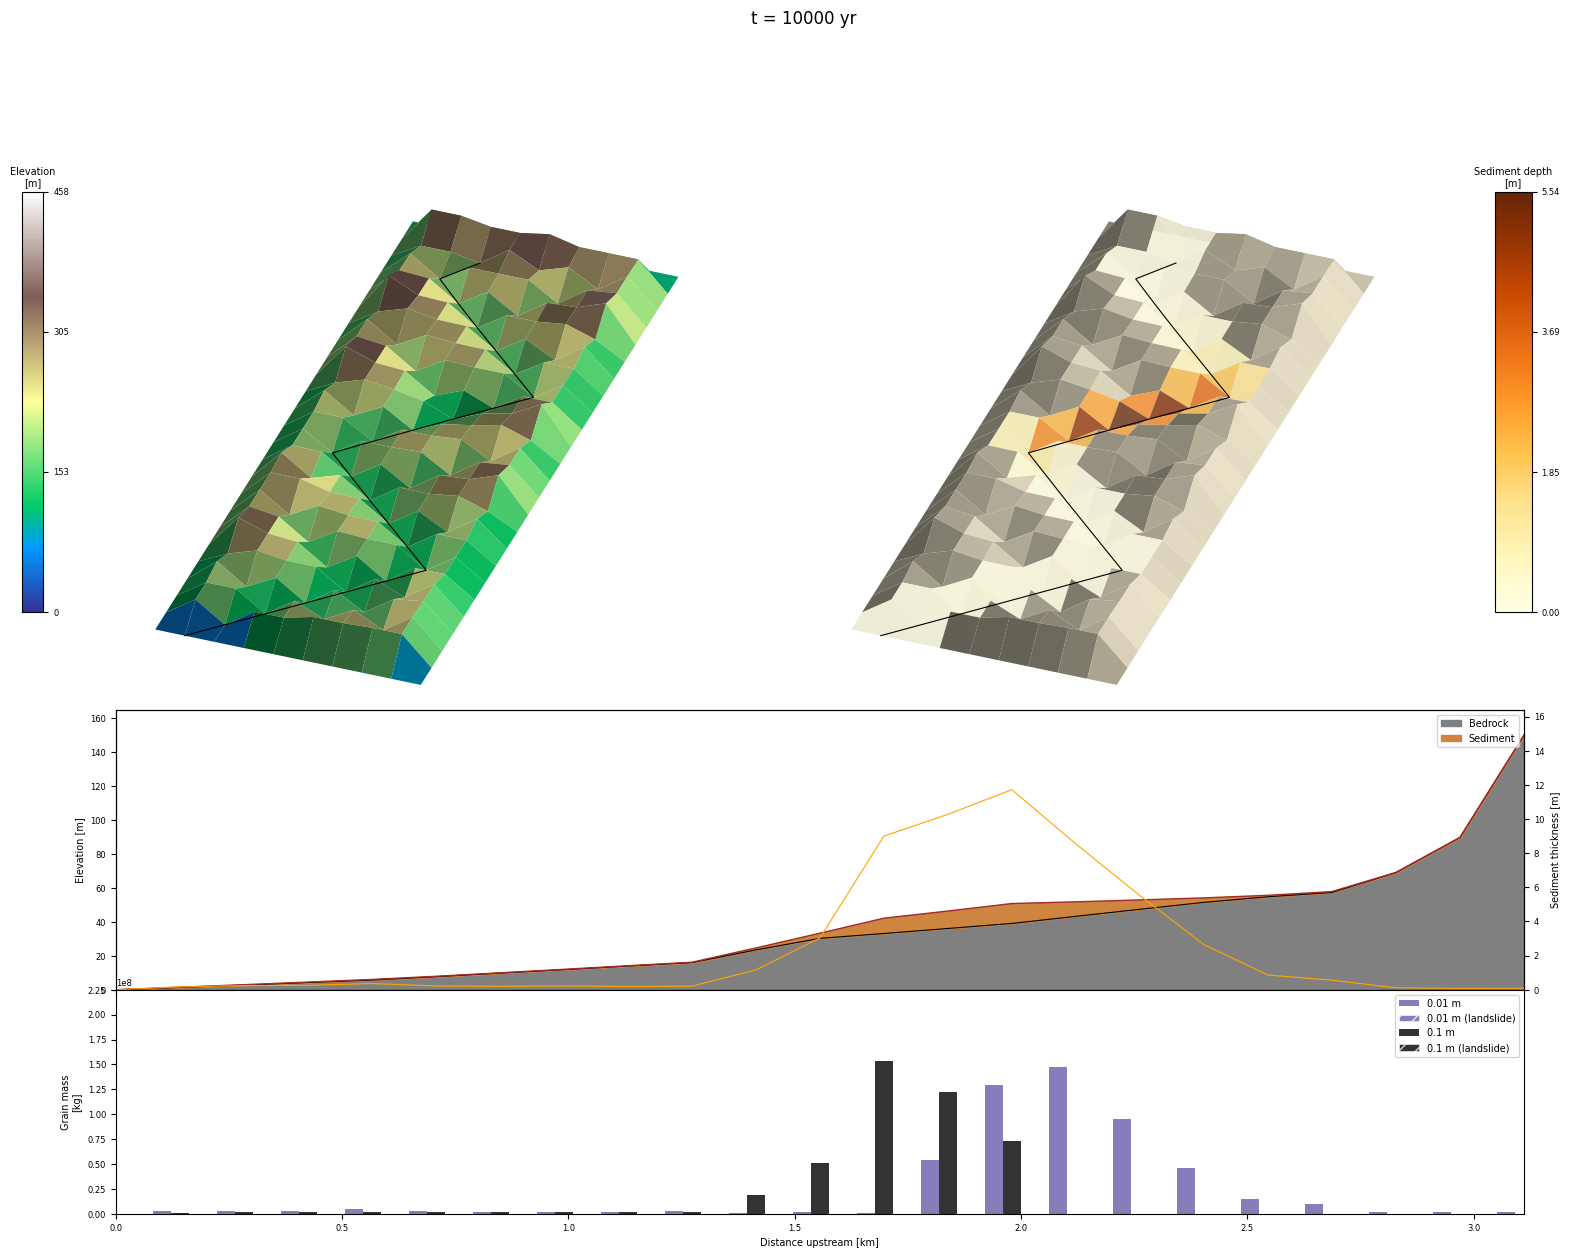

Done — 0.9 min total


In [201]:
uplift_rate   = 1e-3
time_step     = 10
total_time    = 10001      
plot_interval = 1000
show_only_current_ls_sed = True
landslides_enabled = False

start = time.time()

# set up the proporations for landslide deposition, this is new
n_nodes = grid.number_of_nodes
n_classes = 2
ls_sed_proportions = [0, 1]#[0.5, 0.5]
proportions_array = np.tile(ls_sed_proportions, (n_nodes, 1))  # shape (n_nodes, n_classes)

grid.at_node['landslide_grains__weight'] = np.zeros((grid.number_of_nodes, n_classes))

# storing data
grain_history = []
profile_history = []

# setting up fixed axes and ranges
elev_min = grid.at_node['topographic__elevation'].min()
elev_max = grid.at_node['topographic__elevation'].max() + uplift_rate * total_time  # account for uplift

fixed_ranges = {
    'elev':        (elev_min, elev_max),
    'erosion':     (0, 1),       # m — set based on expected max landslide erosion
    'deposition':  (0, 6),       # m
    'relief':      (0, elev_max),  # channel profile y axis
    'soil':        (0, 30),       # m — sediment thickness
    'grain_mass':  (0, 2e8),       # kg — grain mass y axis
}

mpl.rcParams.update({
    'font.size':        8,   # default for everything
    'axes.labelsize':   7,   # x and y axis labels
    'xtick.labelsize':  6,   # tick numbers
    'ytick.labelsize':  6,
    'legend.fontsize':  6,
    'axes.titlesize':   7,
})

# want to capture every landslide event, find where it deposits on the channel and build up a running list to use
all_ls_channel_nodes = []       # accumulates every (time, node, depth) that lands on the channel
all_ls_dep_nodes_full = []      # accumulates every deposition node, channel or not


for i in range(0, total_time, time_step):
    fr.run_one_step()
    eroder.run_one_step(time_step)
    grid.at_node['landslide_grains__weight'] = np.zeros((grid.number_of_nodes, n_classes))
    
    if landslides_enabled:
        ls.run_one_step(time_step)
        dep_nodes = np.where(grid.at_node['landslide__deposition'] > 0)[0]
    
        if len(dep_nodes) > 0:
            # need channel nodes at this same timestep
            profiler_now = ChannelProfiler(
                grid, number_of_watersheds=1,
                minimum_channel_threshold=20000, main_channel_only=True,
            )
            profiler_now.run_one_step()
            ch_nodes_now = (np.concatenate(profiler_now.nodes) if isinstance(profiler_now.nodes, list)
                            else profiler_now.nodes.ravel())
    
            ls_dep_on_channel = np.intersect1d(dep_nodes, ch_nodes_now)
    
            # log everything, channel or not
            for n in dep_nodes:
                all_ls_dep_nodes_full.append({
                    'time': i,
                    'node': n,
                    'depth': grid.at_node['landslide__deposition'][n],
                    'on_channel': n in ls_dep_on_channel,
                })
    
            if len(ls_dep_on_channel) > 0:
                print(f"t={i}: landslide deposition ON CHANNEL at nodes {ls_dep_on_channel.tolist()}")
                for n in ls_dep_on_channel:
                    all_ls_channel_nodes.append(n)
                
        grains_before = grid.at_node['grains__weight'].copy()
        
        sg.update_mass_based_on_outsource_dz(proportions=proportions_array)
    
        landslide_contribution = grid.at_node['grains__weight'] - grains_before
        grid.at_node['landslide_grains__weight'] += np.maximum(landslide_contribution, 0)
    else:
        # clear the landslie things
        grid.at_node['landslide__erosion'][:] = 0.0
        grid.at_node['landslide__deposition'][:] = 0.0

    grid.at_node['bedrock__elevation'][grid.core_nodes] += uplift_rate * time_step
    grid.at_node['topographic__elevation'][:] = (
        grid.at_node['bedrock__elevation'] + grid.at_node['soil__depth']
    )

    if i % plot_interval == 0:
        profiler = ChannelProfiler(
            grid, number_of_watersheds=1,
            minimum_channel_threshold=20000, main_channel_only=True,
        )
        profiler.run_one_step()

        if isinstance(profiler.nodes, list):
            ch_nodes = np.concatenate(profiler.nodes)
        else:
            ch_nodes = profiler.nodes.ravel()
        dists_km = (profiler.distance_along_profile[0].max() - profiler.distance_along_profile[0]) * 1e-3
        grain_history.append({
            'time' : i,
            'grains' : grid.at_node['grains__weight'][ch_nodes].copy(),
            'grains_ls' : grid.at_node['landslide_grains__weight'][ch_nodes].copy(),
            'dists_km' : dists_km,
                })
        profile_history.append({
            'time':    i,
            'dist_km': profiler.distance_along_profile[0] * 1e-3,  # 0 at outlet, max upstream
            'topo':    grid.at_node['topographic__elevation'][ch_nodes].copy(),
            'soil':    grid.at_node['soil__depth'][ch_nodes].copy(),
        })
        #plotting
        fig, axes = plot_3d_landslide_extended(
            grid,
            figsize=(16, 14),
            profiler=profiler,                          # the already-run ChannelProfiler
            grains__weight=grid.at_node['grains__weight'],
            grain_sizes_m=[0.01, 0.1],
            landslide_grains__weight=grid.at_node['landslide_grains__weight'],
            elapsed_time=i,
            z_exag=1.0,
            elev=35, azim=290,
            fixed_ranges=None,#fixed_ranges,
            single_ls_colorbar=True,
            #ls_diverging_cmap=cm.managua,
            hillshade_azimuth=290,
            hillshade_altitude=30,
            topo_base_color='#F5EDD1',
            plot_cumm_landslide=True,
            plot_channel_profs_on_3d=True,
            save_fig=False,
        )
        plt.show()

        ls_e = grid.at_node['landslide__erosion']
        ls_d = grid.at_node['landslide__deposition']
        if landslides_enabled:
            print(f"  landslide erosion  — nodes active: {(ls_e>0).sum():4d}, "
                  f"max dz: {ls_e.max():.3f} m, total vol: {ls_e.sum()*100**2:.1f} m³")
            print(f"  landslide deposit  — nodes active: {(ls_d>0).sum():4d}, "
                  f"max dz: {ls_d.max():.3f} m, total vol: {ls_d.sum()*100**2:.1f} m³")

print(f"Done — {(time.time()-start)/60:.1f} min total")

The result is that a landslide consisting of coarse material (0.1 m) compared to what is in the channel already (0.01 m) will cause an  accumlation of the finer-grained sediment upstream of the coarse landslide deposit. The deposition of the landslide material and this upstream material will cause a local decrease in erosion rates that leads to the development of a knickpoint immediately downstream of the original location of the landslide deposit. 

This example nicely shows how EGBE can be used when asking questions about how different grain sizes interact within channels and how it can be combined with the BedrockLandslider.